# **Mini-Hackathon : Data Storytelling Notebookt**

จัดทำโดย

รหัส: 600817

ชื่อ-นามสกุล: สิทธิศักดิ์ สีหมื่น

---
## Data
> ข้อมูลการนำเข้า–ส่งออกสินค้าประมงของประเทศไทย ปี พ.ศ.2568 :

> ชุดข้อมูลใน THackle: [ชุดข้อมูลการนำเข้า–ส่งออกสินค้าประมงของประเทศไทย](https://www.thackle.or.th/th/dataset/93)


## Overview of Notebook
1. Setup & Load Data
2. Data Preprocessing
3. Advanced EDA & Insights
4. Challenge Questions
5. ALL Summary


# 1.Setup & Load Data
> ติดตั้ง Library ที่จำเป็นและโหลดชุดข้อมูลที่จะใช้

## Setup

In [ ]:
!pip install plotly kaleido -q
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font',family = 'TH Sarabun New',size = 16)
sns.set_theme(style = "whitegrid",font = "TH Sarabun New")
plt.rcParams['figure.dpi'] = 120
print('Import สำเร็จ! พร้อมวิเคราะห์')

Import สำเร็จ! พร้อมวิเคราะห์


## Load Data

In [ ]:
df = pd.read_csv('import_export.csv',encoding = 'utf-8')

# 2.Data Preprocessing

## 2.1 Data Cleaning

### -Missing Value Detection

In [ ]:
print("-" * 60)
print('ช้อมูลภาพรวมการนำเข้า–ส่งออกสินค้าประมงของประเทศไทย')
print("-" * 60)
display(df.head(3))
df.info()

------------------------------------------------------------
ช้อมูลภาพรวมการนำเข้า–ส่งออกสินค้าประมงของประเทศไทย
------------------------------------------------------------


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
0,2568,8,1062000002,BJ,เบนิน,33,90,48080,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
1,2568,8,1062000002,MU,มอริเชียส,10,50,44147,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
2,2568,8,1062000002,BR,บราซิล,8,150,47068,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42057 entries, 0 to 42056
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year             42057 non-null  int64 
 1   month            42057 non-null  int64 
 2   heading11        42057 non-null  int64 
 3   countryID        42032 non-null  object
 4   countryNameTH    42057 non-null  object
 5   weight           42057 non-null  int64 
 6   quantity         42057 non-null  int64 
 7   price            42057 non-null  int64 
 8   tradeflow        42057 non-null  int64 
 9   productDetailEN  42057 non-null  object
 10  productDetailTH  42057 non-null  object
 11  ETL_DATE         42057 non-null  object
dtypes: int64(7), object(5)
memory usage: 3.9+ MB


ภาพรวมของชุดข้อมูล (Overview)

*  จำนวนข้อมูลทั้งหมด: 42,057 รายการ (แถว)

*  จำนวนคอลัมน์: 12 คอลัมน์

*  ประเภทข้อมูล: ประกอบด้วยข้อมูลตัวเลข (int64) 7 คอลัมน์ และข้อมูลข้อความ วันที่ (object) 5 คอลัมน์

*  ความสมบูรณ์ของข้อมูล: ข้อมูลเกือบทั้งหมดมีความสมบูรณ์ ยกเว้นคอลัมน์ countryID ที่มีค่าว่าง (Null) อยู่เล็กน้อย (มีข้อมูล 42,032 จาก 42,057 รายการ หรือหายไป 25 รายการ)

ตรวจสอบ colum countryID ในตำแหน่งที่มีค่าศูนย์หาย

In [ ]:
df[df['countryID'].isnull()]

,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
5580,2568,3,3034100000,NaN,นามิเบีย,194755,194755,16318673,1,Albacore or longfinned tunas(Thunnus alalunga)...,ปลาแอลบาคอร์หรือทูน่าครีบยาวแช่เย็นจนแข็ง ไม่ร...,12/3/2026 5:59
6118,2568,7,3034200000,NaN,นามิเบีย,4452,4452,650647,1,Yellowfin tunas(Thunnus albacares) excluding l...,ปลาทูน่าครีบเหลืองแช่เย็นจนแข็ง ไม่รวมเนื้อปลา...,12/3/2026 5:59
6956,2568,12,3034400000,NaN,นามิเบีย,2500,2500,382881,1,Bigeyes tunas(Thunnus obesus) excluding livers...,ปลาบิกอายทูนา แช่เย็นจนแข็ง ไม่รวมตับและไข่(Bi...,12/3/2026 5:59
6991,2568,7,3034400000,NaN,นามิเบีย,69836,69836,10206334,1,Bigeyes tunas(Thunnus obesus) excluding livers...,ปลาบิกอายทูนา แช่เย็นจนแข็ง ไม่รวมตับและไข่(Bi...,12/3/2026 5:59
8366,2568,10,3039200000,NaN,นามิเบีย,15200,15200,859142,1,Shark fins,ครีบปลาฉลาม (หูฉลาม),12/3/2026 5:59
8380,2568,7,3039200000,NaN,นามิเบีย,26000,26000,1468115,1,Shark fins,ครีบปลาฉลาม (หูฉลาม),12/3/2026 5:59
8546,2568,7,3039900000,NaN,นามิเบีย,26000,921,863597,1,Other,หัวปลา หางปลา กระเพาะปลาและส่วนอื่นของปลาที่บร...,12/3/2026 5:59
20189,2568,1,16041311000,NaN,นามิเบีย,106560,266400,7914733,2,Sardines sardinella and brisling or sprats pre...,ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแ...,12/3/2026 5:59
20223,2568,2,16041311000,NaN,นามิเบีย,395945,1401120,31135949,2,Sardines sardinella and brisling or sprats pre...,ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแ...,12/3/2026 5:59
20251,2568,3,16041311000,NaN,นามิเบีย,159840,399600,11639781,2,Sardines sardinella and brisling or sprats pre...,ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแ...,12/3/2026 5:59


สาเหตุที่เกิดขึ้นเป็นเพราะว่า รหัสประเทศ (ISO 2-letter code) ของประเทศนามิเบียคือตัวอักษร "NA" เวลาที่เราโหลดข้อมูลเข้ามา (เช่น ใช้คำสั่ง pd.read_csv) ตัว Pandas จะถูกตั้งค่าเริ่มต้นไว้ว่า ถ้าเจอคำว่า "NA", "N/A", หรือ "null" มันจะมองว่าเป็น ค่าว่าง (Missing Value) ทันที แล้วแปลงให้เป็น NaN (Not a Number) โดยอัตโนมัติ

### -Fix default NA Parsing

In [ ]:
# เติมตัวอักษร 'NA' ลงไปในช่อง countryID เฉพาะแถวที่ชื่อประเทศเป็น 'นามิเบีย'
df.loc[df['countryNameTH'] == 'นามิเบีย', 'countryID'] = 'NA'
# เช็คผลลัพธ์ว่าหายไปไหม (ผลควรจะออกมาเป็น 0)
print(df['countryID'].isnull().sum())

0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42057 entries, 0 to 42056
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year             42057 non-null  int64 
 1   month            42057 non-null  int64 
 2   heading11        42057 non-null  int64 
 3   countryID        42057 non-null  object
 4   countryNameTH    42057 non-null  object
 5   weight           42057 non-null  int64 
 6   quantity         42057 non-null  int64 
 7   price            42057 non-null  int64 
 8   tradeflow        42057 non-null  int64 
 9   productDetailEN  42057 non-null  object
 10  productDetailTH  42057 non-null  object
 11  ETL_DATE         42057 non-null  object
dtypes: int64(7), object(5)
memory usage: 3.9+ MB


## 2.2 Duplicate Detection

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"🚨 พบข้อมูลที่ซ้ำกันทั้งหมด: {duplicate_count:,.0f} แถว")
print("-" * 60)

if duplicate_count > 0:
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

    print("ตัวอย่างแถวที่ซ้ำกัน:")
    display(duplicates_df)
else:
    print("✨ เยี่ยมมาก! ไม่มีแถวข้อมูลที่ซ้ำกันเลยครับ")

🚨 พบข้อมูลที่ซ้ำกันทั้งหมด: 5 แถว
------------------------------------------------------------
ตัวอย่างแถวที่ซ้ำกัน:


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
29924,2568,1,16055490000,HK,ฮ่องกง,7,1,82,2,Other,ปลาหมึกกระดองและปลาหมึกกล้วยอื่น ๆ ที่ไม่บรรจุ...,12/3/2026 5:59
30193,2568,1,16055490000,HK,ฮ่องกง,7,1,82,2,Other,ปลาหมึกกระดองและปลาหมึกกล้วยอื่น ๆ ที่ไม่บรรจุ...,12/3/2026 5:59
22194,2568,2,16041419000,CU,คิวบา,14400,1200,1929660,2,#NAME?,ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรร...,12/3/2026 5:59
22236,2568,2,16041419000,CU,คิวบา,14400,1200,1929660,2,#NAME?,ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรร...,12/3/2026 5:59
30067,2568,4,16055490000,HK,ฮ่องกง,3,1,40,2,Other,ปลาหมึกกระดองและปลาหมึกกล้วยอื่น ๆ ที่ไม่บรรจุ...,12/3/2026 5:59
30084,2568,4,16055490000,HK,ฮ่องกง,3,1,40,2,Other,ปลาหมึกกระดองและปลาหมึกกล้วยอื่น ๆ ที่ไม่บรรจุ...,12/3/2026 5:59
40953,2568,8,16051014090,HK,ฮ่องกง,1,1,128,2,Other,ปู อื่น ๆ,12/3/2026 5:59
40958,2568,8,16051014090,HK,ฮ่องกง,1,1,128,2,Other,ปู อื่น ๆ,12/3/2026 5:59
23884,2568,12,16041419000,HK,ฮ่องกง,1,1,32,2,#NAME?,ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรร...,12/3/2026 5:59
23891,2568,12,16041419000,HK,ฮ่องกง,1,1,32,2,#NAME?,ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรร...,12/3/2026 5:59


### -Drop Duplicates

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"ลบข้อมูลซ้ำเรียบร้อยแล้ว ข้อมูลปัจจุบันมีทั้งหมด: {len(df):,.0f} แถว")

ลบข้อมูลซ้ำเรียบร้อยแล้ว ข้อมูลปัจจุบันมีทั้งหมด: 42,052 แถว


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42052 entries, 0 to 42051
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year             42052 non-null  int64 
 1   month            42052 non-null  int64 
 2   heading11        42052 non-null  int64 
 3   countryID        42052 non-null  object
 4   countryNameTH    42052 non-null  object
 5   weight           42052 non-null  int64 
 6   quantity         42052 non-null  int64 
 7   price            42052 non-null  int64 
 8   tradeflow        42052 non-null  int64 
 9   productDetailEN  42052 non-null  object
 10  productDetailTH  42052 non-null  object
 11  ETL_DATE         42052 non-null  object
dtypes: int64(7), object(5)
memory usage: 3.9+ MB


สรุปโครงสร้างข้อมูล (หลังการแก้ไข)
1. ขนาดของชุดข้อมูล (Data Size)

   * จำนวนแถว (Rows): เหลือ 42,052 รายการ (ลดลงจาก 42,057 รายการ เนื่องจากตัดข้อมูลที่บันทึกซ้ำซ้อนกันออกไป 5 รายการ)

   * ลำดับแถว (Index): 0 to 42051 ลำดับบรรทัดถูกจัดเรียงใหม่ให้ต่อเนื่องกัน ไม่มีหมายเลขที่กระโดดข้าม (ผลจากการทำ reset_index)

   * จำนวนคอลัมน์ (Columns): 12 คอลัมน์เช่นเดิม
2. ความสมบูรณ์ของข้อมูล (Non-Null Count)

   * ทุกคอลัมน์ระบุว่ามีข้อมูล 42,052 non-null * ความหมาย: จำนวนข้อมูลที่มีในแต่ละคอลัมน์ เท่ากับ จำนวนแถวทั้งหมดพอดีเป๊ะ แสดงว่า "ไม่มีค่าว่าง (Missing Values) หรือค่า Null หลงเหลืออยู่เลยแม้แต่ช่องเดียว" (ปัญหาประเทศนามิเบีย NA ก็ถูกเคลียร์ไปแล้ว)
3. ประเภทของข้อมูลในแต่ละคอลัมน์ (Data Types)
ระบบจัดแบ่งประเภทข้อมูลไว้อย่างถูกต้อง พร้อมสำหรับการนำไปประมวลผลต่อ:

   * int64 (ข้อมูลตัวเลขจำนวนเต็ม) มี 7 คอลัมน์: ได้แก่ ปี (year), เดือน (month), รหัสสินค้า (heading11), น้ำหนัก (weight), ปริมาณ (quantity), มูลค่า (price) และทิศทางการค้า (tradeflow)

   * object (ข้อมูลประเภทข้อความ/ตัวอักษร) มี 5 คอลัมน์: ได้แก่ รหัสประเทศ (countryID), ชื่อประเทศ (countryNameTH), ชื่อสินค้าภาษาอังกฤษ (productDetailEN), ชื่อสินค้าภาษาไทย (productDetailTH) และวันที่อัปเดตข้อมูล (ETL_DATE)

แม้ว่า year (ปี), month (เดือน), และ tradeflow (ทิศทางการค้า) จะถูกบันทึกมาเป็นตัวเลข แต่ในความเป็นจริง มันคือ "หมวดหมู่" หรือ "ป้ายกำกับ" (Categorical Data) ไม่ใช่ตัวเลขที่ใช้แสดงปริมาณ (Numerical Data)

## 2.3 Data Type Conversion

In [ ]:
df['year'] = df['year'].astype(str)
df['month'] = df['month'].astype(str)
df['tradeflow'] = df['tradeflow'].astype(str)
df['heading11'] = df['heading11'].astype(str)
print(df.dtypes)

year               object
month              object
heading11          object
countryID          object
countryNameTH      object
weight              int64
quantity            int64
price               int64
tradeflow          object
productDetailEN    object
productDetailTH    object
ETL_DATE           object
dtype: object


## 2.4 Post-Cleaning Data Summary

1.กลุ่มข้อความและหมวดหมู่ (Data Type: object)
ตอนนี้คอลัมน์ที่เป็น object (ซึ่งใน Pandas หมายถึง ข้อความ หรือ String) มีทั้งหมด 9 คอลัมน์ ได้แก่:

  * year, month, tradeflow: ถูกเปลี่ยนจากตัวเลขเป็นข้อความเรียบร้อยแล้ว ตอนนี้คอมพิวเตอร์จะมองมันเป็น "ป้ายกำกับ" (Label) หรือ "หมวดหมู่" (Category) ไม่ใช่ตัวเลขที่เอาไปบวกเลขกันอีกต่อไป

  * heading11: รหัสสินค้า 11 หลัก กลายเป็นข้อความเต็มตัว ปลอดภัยจากปัญหา "เลข 0 นำหน้าหาย" แน่นอน

  * countryID, countryNameTH, productDetailEN, productDetailTH, ETL_DATE: กลุ่มนี้เป็นข้อความอยู่แล้วตั้งแต่ต้น ใช้สำหรับเป็นข้อมูลอ้างอิงและชื่อเรียก

ประโยชน์: กลุ่มนี้ทั้งหมดจะทำหน้าที่เป็น "แกนในการวิเคราะห์ (Dimensions)" เช่น เอาไว้จัดกลุ่ม (Group By) ว่าจะดูข้อมูลของ ปีไหน เดือนอะไร ประเทศอะไร หรือ สินค้าอะไร

2.กลุ่มตัวเลขที่ใช้คำนวณ (Data Type: int64)
เหลือเพียง 3 คอลัมน์เท่านั้นที่ยังเป็น int64 (ตัวเลขจำนวนเต็ม) ซึ่งถูกต้องและเหมาะสมที่สุดครับ ได้แก่:

  * weight (น้ำหนัก)

  * quantity (ปริมาณ)

  * price (มูลค่าการค้า)

ประโยชน์: กลุ่มนี้ทำหน้าที่เป็น "ตัวชี้วัด (Metrics)" ซึ่งเป็นตัวเลขที่แท้จริง เราสามารถนำ 3 คอลัมน์นี้ไปเข้าสูตรคณิตศาสตร์ได้ฃ เช่น หาผลรวม (Sum), หาค่าเฉลี่ย (Mean) หรือหาค่าสูงสุด/ต่ำสุด (Max/Min)

## 2.5 Column-wise Data Cleaning

### -Year

In [ ]:
year_counts = df['year'].value_counts().sort_index()
print(year_counts)

year
2568    42052
Name: count, dtype: int64


ข้อมูลทั้งหมด 42,052 รายการ ถูกบันทึกไว้ว่าเป็นข้อมูลของ ปี 2568 (พ.ศ. 2568) ทั้งหมด

### -Month

In [ ]:
month_counts = df['month'].value_counts()
month_counts.index = month_counts.index.astype(int)
month_counts = month_counts.sort_index()

print(month_counts)

month
1     3518
2     3487
3     3520
4     3458
5     3652
6     3538
7     3472
8     3518
9     3519
10    3514
11    3354
12    3502
Name: count, dtype: int64


สร้าง Dictionary จับคู่ตัวเลข 1-12 กับชื่อเดือนภาษาไทย

In [ ]:
thai_months = {
    1: 'มกราคม', 2: 'กุมภาพันธ์', 3: 'มีนาคม', 4: 'เมษายน',
    5: 'พฤษภาคม', 6: 'มิถุนายน', 7: 'กรกฎาคม', 8: 'สิงหาคม',
    9: 'กันยายน', 10: 'ตุลาคม', 11: 'พฤศจิกายน', 12: 'ธันวาคม',
    '1': 'มกราคม', '2': 'กุมภาพันธ์', '3': 'มีนาคม', '4': 'เมษายน',
    '5': 'พฤษภาคม', '6': 'มิถุนายน', '7': 'กรกฎาคม', '8': 'สิงหาคม',
    '9': 'กันยายน', '10': 'ตุลาคม', '11': 'พฤศจิกายน', '12': 'ธันวาคม'
}
df['month_th'] = df['month'].map(thai_months)
print(df[['month', 'month_th']].head(10))

  month    month_th
0     8     สิงหาคม
1     8     สิงหาคม
2     8     สิงหาคม
3     8     สิงหาคม
4     9     กันยายน
5     9     กันยายน
6     9     กันยายน
7     1      มกราคม
8     2  กุมภาพันธ์
9     2  กุมภาพันธ์


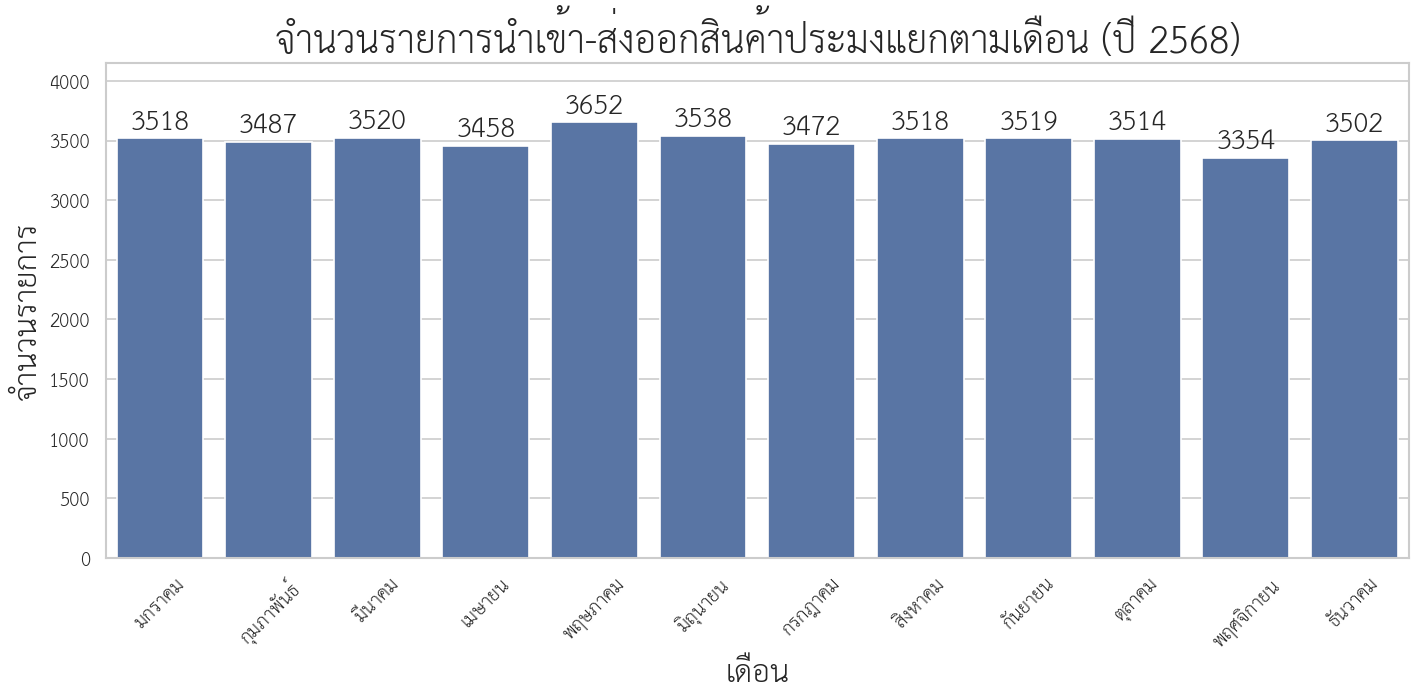

In [ ]:
thai_month_labels = [thai_months[m] for m in month_counts.index]

plt.figure(figsize=(12, 6))

ax = sns.barplot(x=thai_month_labels, y=month_counts.values, color='#4C72B0')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=16)

plt.xlabel('เดือน', fontsize=18, fontweight='bold')
plt.ylabel('จำนวนรายการ', fontsize=18, fontweight='bold')
plt.title('จำนวนรายการนำเข้า-ส่งออกสินค้าประมงแยกตามเดือน (ปี 2568)', fontsize=22, fontweight='bold')
plt.xticks(rotation=45)
plt.ylim(0, max(month_counts.values) + 500)

plt.tight_layout()
plt.show()

ภาพรวมการค้ามีความเสถียรสูง (High Consistency)
เมื่อดูรูปทรงของแท่งกราฟทั้งหมด จะเห็นว่าความสูงแทบจะอยู่ในระดับเดียวกันตลอดทั้งปี (เฉลี่ยเกาะกลุ่มอยู่ที่ประมาณ 3,400 - 3,500 รายการ) สิ่งนี้บอกเราว่า การนำเข้า-ส่งออกสินค้าประมงของไทยในปี 2568 มีการทำธุรกรรมที่สม่ำเสมอมาก

### -CountryID & CountryNameTH

In [ ]:
country_list = df[['countryID', 'countryNameTH']].drop_duplicates().reset_index(drop=True)

display(country_list)

,countryID,countryNameTH
0,BJ,เบนิน
1,MU,มอริเชียส
2,BR,บราซิล
3,EG,อียิปต์
4,KE,เคนยา
...,...,...
192,GS,เกาะเซาท์จอร์เจียและหมู่เกาะเซาท์แซนด์วิช
193,KY,หมู่เกาะเคย์แมน
194,LI,ลิกเตนสไตน์
195,SS,ซูดานใต้


ตรวจสอบรายชื่อประเทศที่มีอักขระที่ไม่ใช่ภาษาไทย

In [ ]:
# [^\u0E00-\u0E7F\s0-9\-\.\(\)] หมายถึง "หาตัวที่ไม่ใช่ (^) ภาษาไทย, ช่องว่าง, ตัวเลข, ขีด, จุด, หรือวงเล็บ"
regex_pattern_non_thai = r'[^\u0E00-\u0E7F\s0-9\-\.\(\)]'
non_thai_strict = country_list[country_list['countryNameTH'].str.contains(regex_pattern_non_thai, na=False, regex=True)]
print("รายชื่อประเทศที่มีอักขระที่ไม่ใช่ภาษาไทย:")
print(non_thai_strict)

รายชื่อประเทศที่มีอักขระที่ไม่ใช่ภาษาไทย:
    countryID                          countryNameTH
12         SR                               Suriname
174        CW                                CURACAO
185        CD  Congo, the Democratic Republic of the


แก้ไขรายชื่อประเทศที่มีอักขระที่ไม่ใช่ภาษาไทย

In [ ]:
# 1. แทนที่ชื่อประเทศใน DataFrame หลัก (df)
df.loc[df['countryID'] == 'SR', 'countryNameTH'] = 'ซูรินาเม'
df.loc[df['countryID'] == 'CW', 'countryNameTH'] = 'กูราเซา'
df.loc[df['countryID'] == 'CD', 'countryNameTH'] = 'สาธารณรัฐประชาธิปไตยคองโก'

# 2. ลองเช็คข้อมูลที่แก้แล้ว (โดยดึงข้อมูลจากรหัสเหล่านั้นมาดู)
check_ids = ['SR', 'CW', 'CD']
print(df[df['countryID'].isin(check_ids)][['countryID', 'countryNameTH']].drop_duplicates())

      countryID              countryNameTH
23           SR                   ซูรินาเม
22170        CW                    กูราเซา
25101        CD  สาธารณรัฐประชาธิปไตยคองโก


In [ ]:
!pip install pycountry -q

In [ ]:
import pycountry
import pandas as pd
from babel import Locale
locale_th = Locale('th')
def get_alpha3(alpha2):
    try:
        return pycountry.countries.get(alpha_2=alpha2).alpha_3
    except:
        return None

country_list['countryID_3'] = country_list['countryID'].apply(get_alpha3)

all_countries = pd.DataFrame([
    {
        'countryID_3': c.alpha_3,
        'countryNameEN': c.name,
        'countryNameTH': locale_th.territories.get(c.alpha_2, c.name)
    }
    for c in pycountry.countries if hasattr(c, 'alpha_2')
])

# 4. หาประเทศที่ไม่อยู่ใน country_list (เทียบจากรหัส 3 หลัก)
our_countries = set(country_list['countryID_3'].dropna())
not_trading = all_countries[~all_countries['countryID_3'].isin(our_countries)].reset_index(drop=True)

# 5. แสดงผลลัพธ์
print(f"🌍 ประเทศที่ไม่ใช่คู่ค้าทั้งหมด: {len(not_trading)} ประเทศ")
display(not_trading[['countryID_3', 'countryNameTH']])

🌍 ประเทศที่ไม่ใช่คู่ค้าทั้งหมด: 53 ประเทศ


,countryID_3,countryNameTH
0,AFG,อัฟกานิสถาน
1,AIA,แองกวิลลา
2,ALA,หมู่เกาะโอลันด์
3,AND,อันดอร์รา
4,ATA,แอนตาร์กติกา
5,ATF,เฟรนช์เซาเทิร์นเทร์ริทอรีส์
6,BDI,บุรุนดี
7,BES,เนเธอร์แลนด์แคริบเบียน
8,BLM,เซนต์บาร์เธเลมี
9,BVT,เกาะบูเว


In [ ]:
import plotly.express as px
import pycountry
import pandas as pd
from babel import Locale
locale_th = Locale('th')

our_countries_set = set(country_list['countryID_3'].dropna())

countries_data = []
for c in pycountry.countries:
    if hasattr(c, 'alpha_2'):

        th_name = locale_th.territories.get(c.alpha_2, c.name)
    else:
        th_name = c.name

    countries_data.append({
        'countryID_3': c.alpha_3,
        'countryNameTH': th_name
    })

all_countries = pd.DataFrame(countries_data)


all_countries['status'] = all_countries['countryID_3'].apply(
    lambda x: 'คู่ค้า' if x in our_countries_set else 'ไม่ใช่คู่ค้า'
)


fig = px.choropleth(
    all_countries,
    locations="countryID_3",
    color="status",
    hover_name="countryNameTH",
    title="<b>แผนที่แสดงประเทศคู่ค้า vs ไม่ใช่คู่ค้า</b>",
    color_discrete_map={
        'คู่ค้าของเรา': '#1a6eb5',
        'ไม่ใช่คู่ค้า': '#f0f0f0'
    }
)


fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="white",
        projection_type='equirectangular'
    ),
    legend_title_text='สถานะการค้า',
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()

### -Weight, Quantity & Price

ตรวจสอบคอลัมน์ข้อมูลเชิงปริมาณ

In [ ]:
num_cols = ['weight', 'quantity', 'price']
print("--- 1. สถิติพื้นฐาน (ภาพรวมข้อมูล) ---")
print(df[num_cols].describe())
print("\n" + "="*50 + "\n")
print("--- 2. เช็คจำนวนรายการที่มีค่าติดลบ (< 0) ---")
negative_counts = (df[num_cols] < 0).sum()
print(negative_counts)
print("\n" + "="*50 + "\n")

print("--- 3. เช็คจำนวนรายการที่มีค่าเป็นศูนย์ (== 0) ---")
zero_counts = (df[num_cols] == 0).sum()
print(zero_counts)
print("\n" + "="*50 + "\n")

print("--- 4. เช็คค่าว่าง (Null / NaN) ---")
null_counts = df[num_cols].isnull().sum()
print(null_counts)

--- 1. สถิติพื้นฐาน (ภาพรวมข้อมูล) ---
             weight      quantity         price
count  4.205200e+04  4.205200e+04  4.205200e+04
mean   8.878430e+04  3.180030e+05  8.931102e+06
std    4.523475e+05  1.268552e+07  4.082716e+07
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    8.800000e+01  2.160000e+02  4.408025e+04
50%    2.701500e+03  3.394000e+03  5.549440e+05
75%    2.600000e+04  3.742200e+04  3.534564e+06
max    1.868457e+07  2.375726e+09  1.157586e+09


--- 2. เช็คจำนวนรายการที่มีค่าติดลบ (< 0) ---
weight      0
quantity    0
price       0
dtype: int64


--- 3. เช็คจำนวนรายการที่มีค่าเป็นศูนย์ (== 0) ---
weight      463
quantity    102
price        12
dtype: int64


--- 4. เช็คค่าว่าง (Null / NaN) ---
weight      0
quantity    0
price       0
dtype: int64


### -Tradeflow

In [ ]:
print(df['tradeflow'].unique())
print(df['tradeflow'].value_counts())
invalid = df[df['tradeflow'].isin([1, 2])]
print(f"จำนวนแถวที่ไม่ใช่ 1 หรือ 2: {len(invalid)}")

['1' '2']
tradeflow
2    28814
1    13238
Name: count, dtype: int64
จำนวนแถวที่ไม่ใช่ 1 หรือ 2: 0


In [ ]:
trade_mapping = {
    1: 'Import',
    2: 'Export',
    '1': 'Import',
    '2': 'Export'
}
df['tradeflow_name'] = df['tradeflow'].map(trade_mapping)
print(df[['tradeflow', 'tradeflow_name']].head())
print("\n--- สรุปจำนวนรายการ Import / Export ---")
print(df['tradeflow_name'].value_counts())

  tradeflow tradeflow_name
0         1         Import
1         1         Import
2         1         Import
3         1         Import
4         1         Import

--- สรุปจำนวนรายการ Import / Export ---
tradeflow_name
Export    28814
Import    13238
Name: count, dtype: int64


In [ ]:
import plotly.express as px

trade_df = df['tradeflow_name'].value_counts().reset_index()
trade_df.columns = ['Trade Type', 'Count']

fig = px.pie(trade_df,
             values='Count',
             names='Trade Type',
             title='<b>สัดส่วนจำนวนรายการ นำเข้า (Import) vs ส่งออก (Export)</b>',
             color='Trade Type',
             color_discrete_map={
                 'Export': '#1f77b4',
                 'Import': '#ff7f0e'
             },
             hole=0.4)

fig.update_traces(textposition='inside', textinfo='percent+label', textfont_size=14)
fig.show()

### -ProductDetailEN, ProductDetailTH

In [ ]:
df['productDetailEN'] = df['productDetailEN'].str.strip()
df['productDetailTH'] = df['productDetailTH'].str.strip()

In [ ]:
df['productDetailEN'] = df['productDetailEN'].str.title()

In [ ]:
print("จำนวนค่าว่าง (Null):")
print(df[['productDetailEN', 'productDetailTH']].isnull().sum())

empty_text = df[(df['productDetailTH'] == '-') | (df['productDetailTH'] == '')]
print(f"\nจำนวนรายการที่เป็นขีดหรือค่าว่างเปล่าๆ: {len(empty_text)} รายการ")

จำนวนค่าว่าง (Null):
productDetailEN    0
productDetailTH    0
dtype: int64

จำนวนรายการที่เป็นขีดหรือค่าว่างเปล่าๆ: 0 รายการ


In [ ]:
import pandas as pd
from IPython.display import display

In [ ]:
summary_data = {
    'รายการตรวจสอบ': ['จำนวนหมวดหมู่สินค้า (ภาษาไทย)', 'จำนวนหมวดหมู่สินค้า (ภาษาอังกฤษ)'],
    'จำนวนที่ไม่ซ้ำกัน (Unique)': [df['productDetailTH'].nunique(), df['productDetailEN'].nunique()]
}
df_unique_summary = pd.DataFrame(summary_data)

print("📊 1. สรุปภาพรวมหมวดหมู่สินค้า")
display(df_unique_summary)
print("\n" + "="*50 + "\n")

top10_th = df['productDetailTH'].value_counts().head(10).reset_index()
top10_th.columns = ['ชื่อสินค้า (ภาษาไทย)', 'จำนวนรายการที่พบ']

print("🇹🇭 2. Top 10 สินค้าที่มีรายการสูงสุด (ภาษาไทย)")
display(top10_th)
print("\n" + "="*50 + "\n")

top10_en = df['productDetailEN'].value_counts().head(10).reset_index()
top10_en.columns = ['ชื่อสินค้า (ภาษาอังกฤษ)', 'จำนวนรายการที่พบ']

print("🇺🇸 3. Top 10 สินค้าที่มีรายการสูงสุด (ภาษาอังกฤษ)")
display(top10_en)

📊 1. สรุปภาพรวมหมวดหมู่สินค้า


,รายการตรวจสอบ,จำนวนที่ไม่ซ้ำกัน (Unique)
0,จำนวนหมวดหมู่สินค้า (ภาษาไทย),431
1,จำนวนหมวดหมู่สินค้า (ภาษาอังกฤษ),204




🇹🇭 2. Top 10 สินค้าที่มีรายการสูงสุด (ภาษาไทย)


,ชื่อสินค้า (ภาษาไทย),จำนวนรายการที่พบ
0,ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรร...,2214
1,ของผสมที่ใช้ปรุงรส และของผสมที่ใช้ชูรสอื่น ๆ,1652
2,อาหารสุนัขหรือแมวที่มีปลาบรรจุภาชนะที่อากาศเข้...,1442
3,ลูกปลาอื่น ๆ มีชีวิต,1111
4,น้ำปลา,1007
5,ปลาอื่นๆปรุงแต่ง,826
6,ปลากัดไทยสวยงามมีชีวิต (เบตาสเพลนเดนส์),804
7,ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโต ที่บรรจุภาช...,796
8,ปลาทองสวยงามมีชีวิต (คารัสเซียสออราทัส),658
9,ปลาหมึกกล้วย แช่เย็นจนแข็ง,610




🇺🇸 3. Top 10 สินค้าที่มีรายการสูงสุด (ภาษาอังกฤษ)


,ชื่อสินค้า (ภาษาอังกฤษ),จำนวนรายการที่พบ
0,(Blank),8689
1,Other,8341
2,#Name?,7584
3,Fish Sauce,1007
4,Surimi Meat,601
5,Yellowfin Tunas(Thunnus Albacares) Excluding L...,563
6,Oscars (Astonotus Ocellatus),553
7,Sardines Sardinella And Brisling Or Sprats Pre...,494
8,Squid Frozen,483
9,Live,431


In [ ]:
error_list = ['(Blank)', 'Other', '#Name?']
check_translation = df[df['productDetailEN'].isin(error_list)][['productDetailEN', 'productDetailTH']].drop_duplicates()
translation_summary = check_translation.groupby('productDetailEN')['productDetailTH'].apply(list).reset_index()
translation_summary.columns = ['ชื่อสินค้า (อังกฤษ)', 'ชื่อสินค้าภาษาไทยที่พบ']

display(translation_summary)

,ชื่อสินค้า (อังกฤษ),ชื่อสินค้าภาษาไทยที่พบ
0,#Name?,[ปลาคาร์ป สวยงามมีชีวิต (แฟนซีคาร์ป) (ไซพรีนสค...
1,(Blank),[เนื้อและส่วนอื่นที่บริโภคได้ของสัตว์เลื้อยคลา...
2,Other,"[ปลาแมคเคอเรลอื่นๆ สดหรือแช่เย็น, หัวปลา หางปล..."


จากการตรวจสอบความสะอาดของข้อมูล (Data Quality) พบว่าคอลัมน์ชื่อสินค้าภาษาอังกฤษ (productDetailEN) มีปัญหาข้อมูลไม่สมบูรณ์และขาดความชัดเจน ดังนี้ครับ:

  * มีค่าผิดปกติและค่าว่าง: ข้อมูลบางแถวแสดงผลเป็น #Name? (เกิดจาก Error ของระบบต้นทาง) หรือขึ้นเป็น (Blank) ทำให้เราไม่รู้เลยว่าสินค้านั้นคืออะไร

  * คำอธิบายกว้างเกินไป: บางรายการใช้คำว่า Other (อื่นๆ) ซึ่งไม่สื่อความหมาย ในขณะที่ฝั่งภาษาไทยระบุรายละเอียดไว้ชัดเจนมาก (เช่น เป็นปลาแมคเคอเรลสด หรือเป็นหัวปลา/หางปลา)

📌 สรุปการตัดสินใจ: เนื่องจากข้อมูลฝั่งภาษาอังกฤษแหว่งและไม่สามารถบอกประเภทสินค้าที่แท้จริงได้ เราจึงจะ ยึดคอลัมน์ productDetailTH (ชื่อสินค้าภาษาไทย) เป็นแกนหลักในการวิเคราะห์และจัดกลุ่มสินค้าทั้งหมด เพื่อให้ผลลัพธ์มีความแม่นยำและเห็น Insight ที่แท้จริง

# 3.Advanced EDA & Insights




## 3.1 Thailand Fishery: Trade Volume (2025)
> วิเคราะห์ตามจำนวนการนำเข้าและส่งออกสินค้าประมงของประเทศไทย ในปี พ.ศ.2568

### -Trade Proportion (สัดส่วนการค้า)
> สัดส่วนจำนวนครั้งระหว่างการนำเข้าเเละส่งออกค้าประมงของประเทศไทยในปี พ.ศ.2568

In [ ]:
import plotly.express as px

trade_df = df['tradeflow_name'].value_counts().reset_index()
trade_df.columns = ['Trade Type', 'Count']

fig = px.pie(trade_df,
             values='Count',
             names='Trade Type',
             title='<b>สัดส่วนจำนวนรายการ นำเข้า (Import) vs ส่งออก (Export)</b>',
             color='Trade Type',
             color_discrete_map={
                 'Export': '#1f77b4',
                 'Import': '#ff7f0e'
             },
             hole=0.4)

fig.update_traces(textposition='inside', textinfo='percent+label', textfont_size=14)
fig.show()

### -Monthly Trade Trends (แนวโน้มการค้ารายเดือน)
> กราฟเเสดงจำนวนครั้งระหว่างการนำเข้าเเละส่งออกค้าประมงของประเทศไทย เเยกตามรายเดือน ในปี พ.ศ.2568

In [ ]:
import plotly.express as px

# 1. เตรียมข้อมูล
line_data = df.groupby(['month', 'month_th', 'tradeflow_name']).size().reset_index(name='count')
line_data['month'] = line_data['month'].astype(int)

# 🌟 สำคัญ: ต้องเรียงลำดับเดือนให้ถูกต้อง (ม.ค. -> ธ.ค.) เพื่อไม่ให้เส้นกราฟวิ่งสลับไปมา
line_data = line_data.sort_values(by=['month'])

# 2. วาดกราฟเส้น
fig = px.line(
    line_data,
    x='month_th',
    y='count',
    color='tradeflow_name',
    markers=True,       # ใส่จุดมาร์คเกอร์
    text='count',       # 🌟 สั่งให้ดึงค่า count มาโชว์เป็นตัวเลขบนกราฟ
    color_discrete_map={'Export': '#1f77b4', 'Import': '#ff7f0e'}, # ล็อคสีให้เหมือนเดิม
    title='<b>📈 แนวโน้มจำนวนรายการนำเข้า-ส่งออกสินค้าประมงรายเดือน (ปี 2568)</b>',
    labels={'month_th': 'เดือน', 'count': 'จำนวนรายการ (ครั้ง)', 'tradeflow_name': 'ทิศทางการค้า'}
)

# 3. ปรับแต่งความสวยงามของเส้นและตัวเลข (Traces)
fig.update_traces(
    textposition="top center",     # ดันตัวเลขให้อยู่เหนือจุด จะได้ไม่ทับเส้น
    texttemplate='%{text:,.0f}',   # ใส่ลูกน้ำ (,) ให้ตัวเลขบนจุดอ่านง่ายขึ้น
    line=dict(width=3),            # ปรับความหนาเส้น
    marker=dict(size=8),           # ปรับขนาดจุดมาร์คเกอร์
    hovertemplate='<b>%{x}</b><br>จำนวนรายการ: %{y:,.0f} ครั้ง<extra></extra>' # ปรับหน้าตา Tooltip ตอนชี้เมาส์
)

# 4. ปรับแต่งเลย์เอาต์ภาพรวม (Layout)
fig.update_layout(
    font=dict(family="TH Sarabun New", size=18),
    height=550,
    hovermode="x unified",
    legend=dict(
        orientation="h",           # ย้าย Legend ไปแนวนอนด้านบน กราฟจะได้กว้างขึ้น
        yanchor="bottom", y=1.05,
        xanchor="right", x=1,
        title=""                   # ซ่อนคำว่า "ทิศทางการค้า" ให้ดูคลีนๆ
    ),
    margin=dict(t=80)              # เว้นที่ว่างด้านบนให้ชื่อกราฟ
)

fig.update_yaxes(tickformat=",")

fig.show()

### -Key Trading Countries
> ประเทศที่มีการส่งออกและนำเข้ามากที่สุด

###  ✏ Summary

> จำนวนครั้งที่นำเข้าและส่งออกสินค้าประมงของประเทศไทย ในปี พ.ศ.2568 คือ 42,052 ครั้ง
---

1. สรุปสัดส่วนครั้งระหว่างการนำเข้าเเละส่งออกค้าประมงของประเทศไทยในปี พ.ศ.2568

      | ประเภท| จำนวน(ครั้ง) |ร้อยละ |
      | :--- | :--- | :--- |
      |นำเข้า | 13,238 | 31.5|
      |ส่งออก | 28,814 | 68.5 |
---

2. ภาพรวมของจำนวนครั้งระหว่างการนำเข้าเเละส่งออกค้าประมงของประเทศไทย เเยกตามรายเดือน สะท้อนให้เห็นว่า
> อุตสาหกรรมประมงไทยมีระบบการกระจายสินค้าที่มีประสิทธิภาพและมีความเป็นพลวัตสูง ข้อมูลนี้ช่วยตอกย้ำภาพลักษณ์ของประเทศไทยในฐานะ "ศูนย์กลางการแปรรูปสินค้าประมงระดับโลก (Global Processing Hub)" ที่มีศักยภาพในการตอบสนองคำสั่งซื้อที่มีความถี่สูงจากคู่ค้าต่างประเทศได้อย่างมีเสถียรภาพ

## 3.2 Import vs. Export: The 3-Dimension Comparison

### -Overall 3-Dimension Comparison (ภาพรวมการเปรียบเทียบใน 3 มิติ)
> เปรียบเทียบสัดส่วนภาพรวมระหว่างการนำเข้าและส่งออกสินค้าประมงของประเทศไทย ทั้งในมิติด้านน้ำหนัก จำนวน และมูลค่ารวม ในปี พ.ศ. 2568

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. หาผลรวมของทั้ง 3 คอลัมน์ แยกตามทิศทางการค้า
summary_df = df.groupby('tradeflow_name')[['weight', 'quantity', 'price']].sum().reset_index()

# 2. สร้างตารางย่อย (Subplots) แบบ 1 แถว 3 คอลัมน์
# สำหรับกราฟวงกลม ต้องกำหนด type เป็น 'domain'
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=('น้ำหนัก (Weight)', 'ปริมาณ (Quantity)', 'มูลค่า (Price)')
)

# กำหนดสีให้คงที่ (น้ำเงิน=Export, ส้ม=Import)
colors_map = {'Export': '#1f77b4', 'Import': '#ff7f0e'}
# ดึงสีตามลำดับของข้อมูลใน summary_df
marker_colors = [colors_map[flow] for flow in summary_df['tradeflow_name']]

# 3. เพิ่มกราฟวงกลมทีละตัวลงไปในแต่ละช่อง

# 🍩 กราฟช่องที่ 1: น้ำหนัก (Weight)
fig.add_trace(go.Pie(
    labels=summary_df['tradeflow_name'],
    values=summary_df['weight'],
    hole=0.4,
    marker_colors=marker_colors,
    textinfo='percent+label',
    hovertemplate='<b>%{label}</b><br>น้ำหนัก: %{value:,.0f} กก.<br>สัดส่วน: %{percent}'
), row=1, col=1)

# 🍩 กราฟช่องที่ 2: ปริมาณ (Quantity)
fig.add_trace(go.Pie(
    labels=summary_df['tradeflow_name'],
    values=summary_df['quantity'],
    hole=0.4,
    marker_colors=marker_colors,
    textinfo='percent+label',
    hovertemplate='<b>%{label}</b><br>ปริมาณ: %{value:,.0f} หน่วย<br>สัดส่วน: %{percent}'
), row=1, col=2)

# 🍩 กราฟช่องที่ 3: มูลค่า (Price)
fig.add_trace(go.Pie(
    labels=summary_df['tradeflow_name'],
    values=summary_df['price'],
    hole=0.4,
    marker_colors=marker_colors,
    textinfo='percent+label',
    hovertemplate='<b>%{label}</b><br>มูลค่า: %{value:,.0f} บาท<br>สัดส่วน: %{percent}'
), row=1, col=3)

# ==========================================
# 4. ปรับแต่งความสวยงามของ Layout
# ==========================================
fig.update_traces(textposition='inside', textfont_size=16)

fig.update_layout(
    title_text='<b>📊 เปรียบเทียบสัดส่วน นำเข้า (Import) vs ส่งออก (Export) ใน 3 มิติหลัก</b>',
    title_x=0.5, # จัดหัวข้อให้อยู่กึ่งกลาง
    font=dict(family="TH Sarabun New", size=18),
    showlegend=False, # ปิด Legend รวม เพราะมี Label บนกราฟแล้ว
    height=500,       # ปรับความสูงกราฟให้พอดีหน้าจอ
    margin=dict(t=120, b=40, l=20, r=20) # ขยายขอบด้านบนไม่ให้ชื่อเรื่องทับกับกราฟ
)

fig.show()

มิติด้านน้ำหนัก (Weight) นำเข้า (Import): 55.3% | ส่งออก (Export): 44.7%
- ในเชิงสสารหรือน้ำหนักมวลรวม ประเทศไทยมีสถานะเป็น "ผู้นำเข้าสุทธิ (Net Importer)" สิ่งนี้บ่งบอกว่าเรามีการกว้านซื้อ "วัตถุดิบตั้งต้น" จากต่างประเทศเข้ามาเป็นจำนวนมหาศาล ซึ่งโดยธรรมชาติวัตถุดิบเหล่านี้ (เช่น ปลาทูน่าแช่แข็งทั้งตัว, ปลาสด) มักจะมีน้ำหนักมาก

มิติด้านปริมาณ (Quantity) นำเข้า (Import): 50.4% | ส่งออก (Export): 49.6%
- จำนวนหน่วย/ชิ้น สัดส่วนการนำเข้าและส่งออกของไทยอยู่ในจุดที่สมดุลกันมากๆ (แทบจะครึ่งต่อครึ่ง) แสดงให้เห็นถึงรอบการหมุนเวียนสินค้าเข้า-ออกที่มีความสม่ำเสมอ

มิติด้านมูลค่า (Price) ส่งออก (Export): 59.4% | นำเข้า (Import): 40.6%
- กราฟนี้คือหัวใจหลักของการค้าไทยครับ! แม้ว่าเราจะส่งออกด้วยน้ำหนักที่ น้อยกว่า ที่เรานำเข้ามา แต่เรากลับกอบโกย "รายได้ (มูลค่า)" ได้สูงถึงเกือบ 60% ของมูลค่าการค้าทั้งหมด ทำให้ไทยเป็น "ผู้ส่งออกสุทธิ (Net Exporter)" ในแง่ของเม็ดเงินและดุลการค้าครับ


### -Monthly Trend Analysis (วิเคราะห์แนวโน้มรายเดือน)

#### 3-Dimension Trade Trends (แนวโน้มการค้ารายเดือนใน 3 มิติ)
  > กราฟแสดงแนวโน้มการนำเข้าและส่งออกสินค้าประมงเป็นรายเดือน เปรียบเทียบการเติบโตตามมิติด้านน้ำหนัก จำนวน และมูลค่า ในปี พ.ศ. 2568

#### **⭐ Challenge Questions ข้อ 3**  

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. เตรียมข้อมูล (เหมือนเดิม)
trend_data = df.groupby(['month', 'month_th', 'tradeflow_name'])[['weight', 'quantity', 'price']].sum().reset_index()
trend_data['month'] = trend_data['month'].astype(int)
trend_data = trend_data.sort_values('month')

df_export = trend_data[trend_data['tradeflow_name'] == 'Export']
df_import = trend_data[trend_data['tradeflow_name'] == 'Import']

# 2. สร้างตารางย่อย แบบ 3 แถว 1 คอลัมน์
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=False,          # 🌟 เปลี่ยนเป็น False เพื่อให้แต่ละกราฟมีแกน X ของตัวเอง
    vertical_spacing=0.12,       # เพิ่มระยะห่างระหว่างกราฟเล็กน้อยเพื่อให้ชื่อเดือนไม่เบียดกับกราฟล่าง
    subplot_titles=('<b>1. แนวโน้ม "น้ำหนัก" (Weight) - กิโลกรัม</b>',
                    '<b>2. แนวโน้ม "ปริมาณ" (Quantity) - หน่วย</b>',
                    '<b>3. แนวโน้ม "มูลค่า" (Price) - บาท</b>')
)

# 3. ฟังก์ชันเพิ่มเส้นกราฟ
def add_trend_lines(metric, row_num):
    # เส้น Export (สีน้ำเงิน)
    fig.add_trace(go.Scatter(
        x=df_export['month_th'], y=df_export[metric],
        mode='lines+markers', name='Export',
        line=dict(color='#1f77b4', width=3), marker=dict(size=8),
        legendgroup='Export', showlegend=(row_num == 1)
    ), row=row_num, col=1)

    # เส้น Import (สีส้ม)
    fig.add_trace(go.Scatter(
        x=df_import['month_th'], y=df_import[metric],
        mode='lines+markers', name='Import',
        line=dict(color='#ff7f0e', width=3), marker=dict(size=8),
        legendgroup='Import', showlegend=(row_num == 1)
    ), row=row_num, col=1)

# 4. วาดกราฟทั้ง 3 ชั้น
add_trend_lines('weight', 1)
add_trend_lines('quantity', 2)
add_trend_lines('price', 3)

# 5. ปรับแต่ง Layout และแกน X ทุกแกน
fig.update_layout(
    title_text='<b>📈 แนวโน้มนำเข้า-ส่งออกสินค้าประมงรายเดือน (เปรียบเทียบ 3 มิติ)</b>',
    title_x=0.5,
    font=dict(family="TH Sarabun New", size=18),
    height=1000,                 # เพิ่มความสูงขึ้นอีกนิดเพื่อให้ดูไม่อึดอัด
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# 🌟 บังคับให้แกน X ทุกอันแสดงชื่อเดือนและหมุนตัวอักษรเพื่อให้อ่านง่าย
fig.update_xaxes(showticklabels=True, tickangle=45)
fig.update_yaxes(tickformat=",") # ใส่คอมม่าให้ตัวเลขแกน Y

fig.show()

1️⃣ มิติน้ำหนัก (Weight — กิโลกรัม)
| ช่วง | Export (น้ำเงิน) | Import (ส้ม) |
|--------|--------|--------|
| Peak | พฤษภาคม (~148M) | มกราคม (218M) + ตุลาคม (188M)
| Low | เมษายน (~132M) |กรกฎาคม–สิงหาคม (~140M)


Import มีน้ำหนักสูงกว่า Export ตลอดทั้งปี และมีความผันผวนสูงกว่ามาก

2️⃣ มิติปริมาณ (Quantity — หน่วย)
| ช่วง | Export (น้ำเงิน) | Import (ส้ม) |
|--------|--------|--------|
| Peak | มกราคม (~540M, ค่อนข้างคงที่) | พฤษภาคม (~2,500M) — พุ่งสูงผิดปกติมาก
| Low | พฤศจิกายน–ธันวาคม (~500M)|กรกฎาคม–ธันวาคม (~150–200M)

⚡Anomaly: Import พุ่งขึ้นสูงมากในช่วงมีนาคม–พฤษภาคม แล้วดิ่งลงหลังมิถุนายน ซึ่งผิดปกติจากมิติอื่นๆ — อาจเป็นสินค้าที่นับ "จำนวนชิ้น/ตัว" เช่น สัตว์น้ำมีชีวิต หรือลูกกุ้ง ซึ่งมีจำนวนหน่วยสูงมากแต่น้ำหนักและมูลค่าไม่สูงตามสัดส่วน

3️⃣ มิติมูลค่า (Price — บาท)
| ช่วง | Export (น้ำเงิน) | Import (ส้ม) |
|--------|--------|--------|
| Peak | พฤษภาคม + ตุลาคม (~20,000M) | มกราคม (~15,000M)
| Low | เมษายน + มิถุนายน (~17,000M)|สิงหาคม (~10,500M)

Export มีมูลค่าสูงกว่า Import ตลอดทั้งปีอย่างชัดเจน (สอดคล้องกับกราฟวงกลมก่อนหน้า)

🔍 สรุป Peak และ Low รวมทุกมิติ
| ช่วง | Peak  | Low |
|--------|--------|--------|
| Export | พฤษภาคม, ตุลาคม |เมษายน, มิถุนายน
|Import| เมกราคม, พฤษภาคม|กรกฎาคม–สิงหาคม


สมมติฐานปัจจัยที่อธิบาย

🎣 ฤดูกาลจับสัตว์น้ำธรรมชาติ

- มกราคม–มีนาคม: ช่วงปลายฤดูหนาว น้ำใสขึ้น → เหมาะจับปลาทะเล → วัตถุดิบไหลเข้าโรงงานมาก → Import น้ำหนักพีคมกราคม
- กรกฎาคม–สิงหาคม: ช่วงมรสุม → ทะเลมีคลื่นสูง → ออกเรือได้น้อย → Import น้ำหนักและมูลค่าต่ำสุด

🦐 ฤดูกาลเพาะเลี้ยงสัตว์น้ำ (Aquaculture Cycle)

- มีนาคม–พฤษภาคม: ช่วง harvest กุ้ง/ปลานิล รอบแรกของปี → ปริมาณ Import พุ่งสูงมาก (สอดคล้องกับ Quantity spike ของ Import ในพฤษภาคม) → น่าจะเป็น ลูกพันธุ์สัตว์น้ำ (Seed/Juvenile) ที่นับจำนวนตัวแล้วสูงมาก

🌍 ความต้องการตลาดโลก (Global Demand)

- ตุลาคม–ธันวาคม: ช่วง Pre-Holiday Season ในสหรัฐฯ และยุโรป (Thanksgiving, -Christmas) → ความต้องการกุ้งและทูน่ากระป๋องเพิ่ม → Export มูลค่าพีคตุลาคม
- เมษายน–พฤษภาคม: ช่วง Easter และ Lent ในตลาดคริสต์ → ความต้องการสัตว์น้ำในยุโรปเพิ่ม → Export พีคพฤษภาคม

🎆 เทศกาลการบริโภคในประเทศ

- มกราคม: ตรุษจีน (ปลาและอาหารทะเลเป็นส่วนหนึ่งของพิธีกรรม) → ดึง Import สูง
- เมษายน (Songkran): ไทยหยุดยาว → กิจกรรมโรงงานชะลอ → อาจเป็นส่วนหนึ่งที่ทำให้ Export/Import ต่ำในเมษายน

📦 วงจรสต็อกสินค้า (Inventory Cycle)

- มกราคม อาจสะท้อนการนำเข้าวัตถุดิบ เติมสต็อกต้นปี หลังจากโรงงานหยุดช่วงสิ้นปี
- ช่วง กรกฎาคม–สิงหาคม ที่ Import ต่ำ อาจเป็นช่วง ระบายสต็อก ก่อนรอบการผลิตใหม่ในไตรมาส 4

ข้อสังเกตพิเศษ: Export มีความ "นิ่ง" (Stable) กว่า Import อย่างมาก โดยเฉพาะมิติน้ำหนักและมูลค่า สะท้อนว่าโรงงานแปรรูปของไทยมีการบริหารการส่งออกที่สม่ำเสมอตลอดปี แต่ วัตถุดิบที่นำเข้านั้นผันผวนตามฤดูกาลและแหล่งผลิต อย่างชัดเจน

#### Market Share of Top 10 Partners (สัดส่วนตลาดรายเดือนของ 10 คู่ค้าหลัก)
> สัดส่วนการกระจายตัวทางการค้ารายเดือนของ 10 ประเทศคู่ค้าหลัก เจาะลึกทั้งฝั่งนำเข้าและส่งออก ตามมิติด้านน้ำหนัก จำนวน และมูลค่า

In [ ]:
import plotly.express as px

# 1. เตรียมข้อมูล Metric ทั้ง 3 มิติ (ชื่อคอลัมน์, ชื่อภาษาไทย, หน่วย)
metrics_to_plot = [
    {'col': 'weight', 'name': 'น้ำหนัก', 'unit': 'กิโลกรัม'},
    {'col': 'quantity', 'name': 'ปริมาณ', 'unit': 'หน่วย'},
    {'col': 'price', 'name': 'มูลค่า', 'unit': 'บาท'}
]

# 2. สร้างฟังก์ชันสำหรับวาดกราฟพื้นที่วางซ้อน
def create_stacked_area(trade_flow, flow_name, metric_col, metric_name, unit, color_seq):
    # กรองเฉพาะทิศทางการค้าที่ต้องการ (Import / Export)
    df_flow = df[df['tradeflow_name'] == trade_flow]

    # หา Top 10 ประเทศเฉพาะตามตัวชี้วัดนั้นๆ (เพื่อให้ได้ตัวท็อปของมิตินั้นจริงๆ)
    top10_countries = df_flow.groupby('countryNameTH')[metric_col].sum().nlargest(10).index
    df_top10 = df_flow[df_flow['countryNameTH'].isin(top10_countries)]

    # จัดกลุ่มรวมยอดแยกตาม เดือน และ ประเทศ
    monthly_area = df_top10.groupby(['month', 'month_th', 'countryNameTH'])[metric_col].sum().reset_index()
    monthly_area['month'] = monthly_area['month'].astype(int)

    # เรียงเดือนให้ถูกต้อง (ม.ค. -> ธ.ค.)
    monthly_area = monthly_area.sort_values(by=['month'])

    # ไอคอนสำหรับชื่อกราฟ
    icon = "📥" if trade_flow == 'Import' else "📤"

    # วาดกราฟ
    fig = px.area(
        monthly_area,
        x="month_th",
        y=metric_col,
        color="countryNameTH",
        title=f"<b>{icon} ภาพรวมสัดส่วนตลาด '{flow_name}' รายเดือน (มิติ: {metric_name})</b>",
        labels={metric_col: f'{metric_name}รวม ({unit})', 'month_th': 'เดือน', 'countryNameTH': 'ประเทศ'},
        color_discrete_sequence=color_seq,
        category_orders={"countryNameTH": top10_countries} # 🌟 บังคับเรียงประเทศยอดเยอะให้อยู่ฐานล่างสุด
    )

    # ปรับแต่ง Layout
    fig.update_layout(
        font=dict(family="TH Sarabun New", size=18),
        height=550,
        hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1),
        margin=dict(t=80)
    )

    # ใส่ลูกน้ำให้แกน Y
    fig.update_yaxes(tickformat=",")
    fig.show()

# =========================================================
# 3. สั่งรันฟังก์ชันเพื่อสร้างกราฟทั้งหมด 6 ตัว
# =========================================================
print("กำลังสร้างกราฟ Stacked Area Chart ทั้ง 3 มิติ... (โปรดเลื่อนลงเพื่อดูกราฟทั้งหมด)\n")

for m in metrics_to_plot:
    print(f"▶️ กำลังประมวลผลมิติ: {m['name']} ...")

    # วาดกราฟฝั่งส่งออก (โทนสี Prism - ตัดกันชัดเจน)
    create_stacked_area('Export', 'ส่งออก', m['col'], m['name'], m['unit'], px.colors.qualitative.Prism)

    # วาดกราฟฝั่งนำเข้า (โทนสี Safe - ดูสบายตา)
    create_stacked_area('Import', 'นำเข้า', m['col'], m['name'], m['unit'], px.colors.qualitative.Safe)

กำลังสร้างกราฟ Stacked Area Chart ทั้ง 3 มิติ... (โปรดเลื่อนลงเพื่อดูกราฟทั้งหมด)

▶️ กำลังประมวลผลมิติ: น้ำหนัก ...


▶️ กำลังประมวลผลมิติ: ปริมาณ ...


▶️ กำลังประมวลผลมิติ: มูลค่า ...


1. ฝั่งส่งออก (สหรัฐอเมริกา & ญี่ปุ่น)
- ทุกเดือนตลอดปี: ถ้าดูกราฟส่งออกทั้ง 3 มิติ แถบสีฐานรากคือ สหรัฐฯ (สีม่วง/น้ำเงินเข้ม) และ ญี่ปุ่น (สีฟ้า/เขียวอมฟ้า) สองประเทศนี้สั่งซื้อสม่ำเสมอมาก เป็นเส้นขนานไปตลอดปี

- พฤษภาคม (เดือนพีค): แถบสีของสหรัฐฯ และญี่ปุ่น หนาตัวขึ้นพร้อมกันอย่างเห็นได้ชัดในเดือนพฤษภาคม (ภูเขาปูดขึ้นไปสูงสุด) แสดงว่าเป็นรอบการส่งมอบสินค้าล็อตใหญ่ที่สุดของปี

- ตุลาคม - ธันวาคม: แถบสีของทั้งสองประเทศกลับมาหนาและยกตัวสูงอีกครั้งในไตรมาส 4 สะท้อนถึงการสั่งออเดอร์เพื่อเตรียมสต็อกสำหรับเทศกาลปลายปี

2. ฝั่งนำเข้า: แหล่งวัตถุดิบหนัก (พม่า & จีน)
- มกราคม - มีนาคม (ต้นปี) & ตุลาคม - ธันวาคม (ปลายปี): ให้ดูกราฟ นำเข้ามิติน้ำหนัก ครับ แถบสีฟ้าล่างสุดคือ พม่า และสีชมพูคือ จีน จะเห็นว่าภูเขาสูงมากในช่วงต้นปีและปลายปี นี่คือช่วงที่ไทย "กว้านซื้อวัตถุดิบหนักๆ" (เช่น ปลาสด/ปลาแช่แข็ง) เข้ามาตุนในห้องเย็น

- มิถุนายน - สิงหาคม: แถบสีของพม่าและจีน "ลีบแบนลง" อย่างชัดเจน (กราฟตกท้องช้าง) เป็นช่วง Low Season ของการนำเข้าวัตถุดิบ อาจจะเพราะเป็นช่วงพักอ่าว หรือสต็อกต้นปีมีเพียงพอแล้ว

3. ฝั่งนำเข้า: ปรากฏการณ์เดือนพฤษภาคม (นาอูรู & ตูวาลู)
- พฤษภาคมเดือนเดียว: กราฟ นำเข้ามิติปริมาณ คือกราฟที่พีคท จู่ๆ ภูเขาก็พุ่งทะลุอวกาศในเดือนพฤษภาคม โดยเกิดจากแถบสีฟ้าอ่อน (นาอูรู) และ สีชมพู (ตูวาลู)

- คำอธิบาย: มมติฐานเชิงฤดูกาล (Seasonal Event): อาจเป็นการนำเข้า "ลูกพันธุ์สัตว์น้ำ" หรือวัตถุดิบขนาดจิ๋วจำนวนมหาศาล เพื่อเริ่มฤดูกาลเพาะเลี้ยงในไทยในช่วงต้นฤดูฝน ความคลาดเคลื่อนของข้อมูล (Data Entry Error) [🌟 ข้อสังเกตสำคัญ]: เมื่อตรวจสอบลึกลงไปถึงรายชื่อสินค้า พบว่าสินค้าหลักคือ "ปลาบิกอายทูน่าแช่เย็นจนแข็ง" ซึ่งเป็นปลาขนาดใหญ่ ไม่ใช่ลูกพันธุ์สัตว์น้ำ จึงมีความเป็นไปได้สูงมากที่จะเกิดความผิดพลาดจากฝั่งผู้บันทึกข้อมูลศุลกากร (Human Error) เช่น: การใช้หน่วยนับผิดประเภท: บันทึกปริมาณเป็น "ตัว" แทนที่จะเป็น "กิโลกรัม"
การคีย์ตัวเลขผิดหลัก: ใส่ตัวเลขหรือจุดทศนิยมเกินจริง
ส่งผลให้ข้อมูลในมิติ "ปริมาณ (Quantity)" ของสองประเทศนี้กลายเป็นค่าที่สูงผิดปกติอย่างสุดขั้ว (Extreme Outlier) และบิดเบือนสัดส่วนของกราฟ
4. ฝั่งนำเข้า: ความนิ่งของสายพรีเมียม (นอร์เวย์)
- ทุกเดือนตลอดปี: ให้ดูกราฟ นำเข้ามิติมูลค่าโฟกัสไปที่แถบ สีชมพู (นอร์เวย์) ครับ
คำอธิบาย: ในขณะที่แถบสีของจีนหรือประเทศอื่นๆ ยุบๆ พองๆ ตามฤดูกาล แต่แถบสีชมพูของนอร์เวย์กลับมีความหนาที่ "เท่ากัน" และขนานเป็นเส้นตรงตั้งแต่ ม.ค. ถึง ธ.ค. บ่งบอกว่าคนไทยบริโภคปลาแซลมอนนำเข้าอย่างสม่ำเสมอทุกเดือน ไม่สนฤดูกาลครับ

5. ฝั่งนำเข้า: ม้ามืดไตรมาส 4 (อินเดีย)
- ตุลาคม - ธันวาคม: กลับมาดูกราฟนำเข้ามูลค่า อีกครั้ง สังเกตแถบ สีเหลืองทอง (อินเดีย) ครับ
คำอธิบาย: ในช่วงครึ่งปีแรก แถบสีเหลืองของอินเดียจะบางๆ แต่พอเข้าสู่เดือนตุลาคมเป็นต้นไป แถบสีเหลืองอ้วนขึ้นอย่างรวดเร็ว นี่คือพฤติกรรมการเป็น "ซัพพลายเออร์ปลายปี" ที่ส่งออกวัตถุดิบ (เช่น กุ้ง หรือทูน่า) มาให้ไทยในช่วงที่วัตถุดิบจากแหล่งอื่นอาจจะเริ่มขาดแคลนครับ

#### Trends of Top 5 Fishery Products (แนวโน้มรายเดือนของ 5 อันดับสินค้าประมงหลัก)
> กราฟแสดงความเคลื่อนไหวรายเดือนของสินค้าประมงนำเข้าและส่งออกยอดนิยม 5 อันดับแรก เพื่อวิเคราะห์แนวโน้มและความผันผวนตามฤดูกาล (Seasonality)

In [ ]:
import plotly.express as px

def create_top_products_line_chart(trade_flow, flow_name, metric, metric_name, unit):
    # 1. กรองเฉพาะทิศทางการค้าที่ต้องการ (Import หรือ Export)
    df_flow = df[df['tradeflow_name'] == trade_flow]

    # 2. หา Top 5 สินค้าที่มี "ยอดรวมทั้งปี" สูงสุด
    top5_products = df_flow.groupby('productDetailTH')[metric].sum().nlargest(5).index

    # 3. กรองข้อมูลให้อยู่แค่ 5 สินค้าตัวท็อปนี้
    df_top5 = df_flow[df_flow['productDetailTH'].isin(top5_products)]

    # 4. จัดกลุ่มรวมยอดแยกตามเดือนและชื่อสินค้า
    monthly_trend = df_top5.groupby(['month', 'month_th', 'productDetailTH'])[metric].sum().reset_index()
    monthly_trend['month'] = monthly_trend['month'].astype(int)

    # 5. เรียงลำดับเดือนให้ถูกต้อง (ม.ค. -> ธ.ค.)
    monthly_trend = monthly_trend.sort_values(by=['month'])

    # 🌟 6. ตัดชื่อสินค้าให้สั้นลงอีกนิด (ลดเหลือ 35 ตัวอักษร) เพื่อให้บรรทัดไม่ล้นเกินไป
    monthly_trend['product_short'] = monthly_trend['productDetailTH'].astype(str).str[:35] + "..."

    # 7. วาดกราฟเส้น
    fig = px.line(
        monthly_trend,
        x='month_th',
        y=metric,
        color='product_short',
        markers=True,
        title=f'<b>📈 แนวโน้มรายเดือน: Top 5 สินค้า "{flow_name}" (มิติ: {metric_name})</b>',
        labels={'month_th': 'เดือน', metric: f'{metric_name} ({unit})', 'product_short': ''}
    )

    # 🌟 8. ปรับแก้ Layout เพื่อแก้ปัญหาข้อความทับกัน
    fig.update_layout(
        font=dict(family="TH Sarabun New", size=18),
        height=650, # เพิ่มความสูงรวมของกราฟเพื่อรองรับพื้นที่ด้านล่าง
        hovermode="x unified",
        legend=dict(
            orientation="h",   # แนวนอน
            yanchor="top",     # ยึดจากขอบบนของกล่องข้อความ
            y=-0.2,            # 🌟 สำคัญ! ติดลบแปลว่าดึงลงมาอยู่ 'ใต้' แกน X
            xanchor="center",  # จัดให้อยู่กึ่งกลางหน้าจอ
            x=0.5,
            title=""           # ซ่อนคำว่า product_short
        ),
        margin=dict(t=80, b=150) # 🌟 ลดขอบบน (t) ให้พอดีชื่อกราฟ และเพิ่มขอบล่าง (b) เผื่อที่ให้ Legend
    )

    # ใส่ลูกน้ำให้แกน Y
    fig.update_yaxes(tickformat=",")
    fig.show()

metrics_to_plot = [
    {'col': 'weight', 'name': 'น้ำหนักรวม', 'unit': 'กก.'},
    {'col': 'quantity', 'name': 'ปริมาณรวม', 'unit': 'หน่วย'},
    {'col': 'price', 'name': 'มูลค่ารวม', 'unit': 'บาท'}
]

print("กำลังสร้างกราฟเส้นแนวโน้ม 3 มิติ... (โปรดเลื่อนลงเพื่อดูกราฟทั้งหมด)\n")

for m in metrics_to_plot:
    print(f"▶️ มิติ: {m['name']}")
    create_top_products_line_chart('Import', 'นำเข้า', m['col'], m['name'], m['unit'])
    create_top_products_line_chart('Export', 'ส่งออก', m['col'], m['name'], m['unit'])

กำลังสร้างกราฟเส้นแนวโน้ม 3 มิติ... (โปรดเลื่อนลงเพื่อดูกราฟทั้งหมด)

▶️ มิติ: น้ำหนักรวม


▶️ มิติ: ปริมาณรวม


▶️ มิติ: มูลค่ารวม


###  ✏ Summary
1. ภาพรวมสัดส่วนการค้า (มกราคม - ธันวาคม 2568)
- จากกราฟวงกลม (รูปที่ 1) และกราฟเส้นเปรียบเทียบ (รูปที่ 2) พบ Insight ที่สำคัญคือ:

- ไทยเน้นนำเข้า "น้ำหนัก" แต่ส่งออก "มูลค่า": เรานำเข้าน้ำหนักสินค้ามากกว่าส่งออก (55.3% vs 44.7%) แต่เราสามารถส่งออกด้วยมูลค่าที่สูงกว่านำเข้าอย่างชัดเจน (59.4% vs 40.6%)

- โมเดล Processing Hub: ข้อมูลนี้ยืนยันว่าไทยนำเข้าวัตถุดิบ (Raw Material) ที่มีน้ำหนักมาก ราคาถูก ➡️ มาแปรรูป ➡️ และส่งออกเป็นสินค้าสำเร็จรูปที่มีมูลค่าเพิ่ม (Value-Added) สูงขึ้น

2. เจาะลึกสินค้า "นำเข้า" (Import Insights)
- หัวใจหลักคือทูน่า: ปลาสคิปแจ็ค (Skipjack Tuna) คือสินค้าพึ่งพาหลักในมิติน้ำหนักและมูลค่า (รูปที่ 3, 7) โดยมียอดนำเข้าสูงมากในช่วงต้นปี (มกราคม) เพื่อตุนสต็อกวัตถุดิบ

- ปรากฏการณ์ในเดือนพฤษภาคม: มีการนำเข้า ปลาบิกอายทูน่า (Bigeye Tuna) พุ่งสูงขึ้นผิดปกติในมิติของ "ปริมาณหน่วย" (รูปที่ 5) แต่ไม่ได้มีน้ำหนักหรือมูลค่าพุ่งตามในสัดส่วนเดียวกัน ซึ่งอาจเป็นสินค้าขนาดเล็กแต่จำนวนชิ้นมาก

- ความต้องการปลาหมึก: ปลาหมึกกล้วย (Squid) มียอดนำเข้าค่อนข้างสม่ำเสมอและเป็นสินค้ามูลค่าสูงอันดับต้นๆ ของฝั่งนำเข้า

3. เจาะลึกสินค้า "ส่งออก" (Export Insights)
- ทูน่ากระป๋องและอาหารสัตว์เลี้ยงคือแชมป์: สินค้ากลุ่ม ปลาทูน่าแปรรูป (สคิปแจ็ค/โบนิโต) และ อาหารสุนัข/แมว ครองอันดับ 1 และ 2 ในทุกมิติ (รูปที่ 4, 6, 8) โดยมียอดส่งออกที่ "นิ่งและเสถียร" กว่าฝั่งนำเข้ามาก สะท้อนถึงคำสั่งซื้อล่วงหน้าที่สม่ำเสมอ

- กุ้งขาว (White Shrimp): เป็นสินค้าที่มีฤดูกาลชัดเจน โดยปริมาณส่งออกจะเริ่มไต่ระดับสูงขึ้นในช่วงเดือนพฤษภาคมถึงกันยายน (รูปที่ 6) ซึ่งสอดคล้องกับรอบการเพาะเลี้ยงในประเทศ

- มูลค่าการส่งออก: มิติมูลค่า (รูปที่ 8) แสดงให้เห็นว่าทูน่าแปรรูปสร้างรายได้ทิ้งห่างสินค้าตัวอื่นอย่างชัดเจน (แตะระดับ 5-6 พันล้านบาทต่อเดือน)

4. บทสรุปเชิงยุทธศาสตร์ (Strategic Summary)
- ช่วง Peak ของปี: อุตสาหกรรมประมงไทยจะคึกคักที่สุดในเดือน พฤษภาคม และ ตุลาคม (มิติมูลค่า) ซึ่งมักจะเป็นช่วงที่คู่ค้าต่างประเทศเตรียมสต็อกสินค้าสำหรับเทศกาล

- ความเสี่ยงที่ต้องระวัง: เนื่องจากไทยพึ่งพาการนำเข้าปลาสคิปแจ็ค (Skipjack) เป็นวัตถุดิบหลักสูงมาก หากราคาตลาดโลกหรือปริมาณการจับในมหาสมุทรผันผวน จะส่งผลกระทบโดยตรงต่อต้นทุนการผลิตทูน่ากระป๋องและอาหารสัตว์เลี้ยงซึ่งเป็นรายได้หลักของประเทศครับ

In [ ]:
import plotly.express as px

# เพิ่มพารามิเตอร์ metric (ชื่อคอลัมน์), metric_name (ชื่อภาษาไทย), และ unit (หน่วย)
def create_country_product_treemap(trade_flow, flow_name, color_scale, metric, metric_name, unit):
    # 1. กรองข้อมูลเฉพาะทิศทางการค้าที่ต้องการ (Import หรือ Export)
    df_flow = df[df['tradeflow_name'] == trade_flow]

    # 2. หา Top 10 ประเทศที่มี "ผลรวม (Sum)" สูงสุดในฝั่งนั้นๆ
    # 🌟 เปลี่ยนจาก .size() เป็นหาผลรวมของคอลัมน์ metric ที่เลือก
    top10_countries = df_flow.groupby('countryNameTH')[metric].sum().nlargest(10).index

    # 3. กรองข้อมูลให้อยู่แค่ใน 10 ประเทศนี้
    df_top10 = df_flow[df_flow['countryNameTH'].isin(top10_countries)]

    # 4. จัดกลุ่ม "หาผลรวม" แยกตามประเทศและชื่อสินค้า
    country_prod = df_top10.groupby(['countryNameTH', 'productDetailTH'])[metric].sum().reset_index()

    # 🌟 ป้องกัน Error ของ Treemap: กรองเอาเฉพาะข้อมูลที่มากกว่า 0 เท่านั้น
    country_prod = country_prod[country_prod[metric] > 0]

    # 5. ตัดชื่อสินค้าให้ยาวไม่เกิน 50 ตัวอักษร
    country_prod['product_short'] = country_prod['productDetailTH'].astype(str).str[:50] + "..."

    # 6. สร้างกราฟ Treemap
    fig = px.treemap(
        country_prod,
        path=[px.Constant(f"รวมยอด{flow_name} (Top 10 ประเทศ)"), 'countryNameTH', 'product_short'],
        values=metric,  # 🌟 ใช้ค่า metric (เช่น price) เป็นตัวกำหนดขนาดพื้นที่
        title=f'<b>🗺️ โครงสร้างประเภทสินค้า "{flow_name}" แยกตามประเทศ (เกณฑ์: {metric_name})</b>',
        color=metric,   # ไล่สีตามค่า metric
        color_continuous_scale=color_scale
    )

    # 7. ปรับแต่งหน้าตาและการแสดงผลตอน Hover ให้ใส่คอมม่าลูกน้ำ (,)
    fig.update_layout(
        font=dict(family="TH Sarabun New", size=18),
        margin=dict(t=50, l=25, r=25, b=25),
        height=700
    )
    fig.update_traces(
        hovertemplate=f'<b>%{{label}}</b><br>{metric_name}: %{{value:,.0f}} {unit}',
        textfont_size=16
    )

    fig.show()


# เตรียมข้อมูล Metric ที่ต้องการ (คอลัมน์, ชื่อไทย, หน่วย, โทนสีนำเข้า, โทนสีส่งออก)
metrics_to_plot = [
    {'col': 'weight', 'name': 'น้ำหนักรวม', 'unit': 'กก.', 'color_imp': 'Oranges', 'color_exp': 'Blues'},
    {'col': 'quantity', 'name': 'ปริมาณรวม', 'unit': 'หน่วย', 'color_imp': 'Reds', 'color_exp': 'Greens'},
    {'col': 'price', 'name': 'มูลค่ารวม', 'unit': 'บาท', 'color_imp': 'Purples', 'color_exp': 'Teal'}
]

# วนลูปสร้างกราฟออกมาทีละตัว
for m in metrics_to_plot:
    print(f"\nกำลังสร้างกราฟ Treemap สำหรับเกณฑ์: {m['name']} ...")
    create_country_product_treemap('Import', 'นำเข้า', m['color_imp'], m['col'], m['name'], m['unit'])
    create_country_product_treemap('Export', 'ส่งออก', m['color_exp'], m['col'], m['name'], m['unit'])


กำลังสร้างกราฟ Treemap สำหรับเกณฑ์: น้ำหนักรวม ...



กำลังสร้างกราฟ Treemap สำหรับเกณฑ์: ปริมาณรวม ...



กำลังสร้างกราฟ Treemap สำหรับเกณฑ์: มูลค่ารวม ...


###  ✏ Summary
1. ⚖️ มิติน้ำหนัก (Weight): "เส้นทางขนส่งและวัตถุดิบหนัก"
- 📥 ฝั่งนำเข้า : พม่า ครองพื้นที่ใหญ่ที่สุดด้วยสีน้ำตาลเข้ม ตามด้วยญี่ปุ่น อินเดีย และจีน ภายในกล่องของพม่าจะเห็นสินค้ากลุ่ม "ปลาทะเลอื่นๆ สดแช่เย็น" เป็นบล็อกใหญ่สุด นี่คือการนำเข้าวัตถุดิบต้นน้ำ (Raw Materials) ล็อตใหญ่ผ่านพรมแดนเพื่อป้อนโรงงานไทย

- 📤 ฝั่งส่งออก : สหรัฐอเมริกา และ จีน เป็นตลาดหลักที่รองรับน้ำหนักสินค้าไทยมากที่สุด สังเกตในกล่องของสหรัฐฯ บล็อกใหญ่สุดคือ "ปลาทูน่าสคิปแจ็คบรรจุภาชนะ" และ "อาหารสุนัข/แมว"

2. 📦 มิติปริมาณ (Quantity):
- 📥 ฝั่งนำเข้า : มิตินี้มีความผิดปกติ (Anomaly) ที่น่าสนใจมากครับ! นาอูรู (Nauru) กลายเป็นยักษ์ใหญ่สีแดงเข้มที่กินพื้นที่เกือบทั้งกราฟ ตามด้วยตูวาลู และไมโครนีเซีย สินค้าในนั้นคือ "ปลาบิกอายทูน่า"

  - Insight: การที่น้ำหนักน้อยแต่นับชิ้นได้มหาศาลขนาดนี้ มักจะเป็นการนำเข้าสินค้าขนาดจิ๋ว เช่น ลูกปลาวัยอ่อน (Fry) หรือวัตถุดิบขนาดเล็กมากๆ จากหมู่เกาะแปซิฟิก

- 📤 ฝั่งส่งออก : สหรัฐอเมริกา และ ญี่ปุ่น ครองแชมป์ตามปกติ สะท้อนถึงการส่งออกสินค้าสำเร็จรูปที่นับเป็นชิ้น/กระป๋อง/ซอง ในปริมาณที่สูงมาก

3. 💰 มิติมูลค่า (Price): "เส้นทางของเม็ดเงิน"
- 📥 ฝั่งนำเข้า : จีน อินเดีย และไต้หวัน คือแหล่งที่เราจ่ายเงินซื้อวัตถุดิบมากที่สุด แต่ที่ต้องไฮไลท์คือ นอร์เวย์ (กล่องซ้ายล่าง) * Insight: นอร์เวย์แทบไม่มีบทบาทในกราฟน้ำหนักและปริมาณเลย แต่กลับโผล่มาเป็นก้อนใหญ่ในกราฟมูลค่า พร้อมบล็อกสินค้า "ปลาแซลมอนแอตแลนติกสด" นี่คือเครื่องยืนยันว่าเรานำเข้า "ของแพง (Premium Value)" จากนอร์เวย์ครับ

- 📤 ฝั่งส่งออก : สหรัฐอเมริกา เป็นมหาอำนาจสีน้ำเงินเข้มที่ทิ้งห่างทุกประเทศ ตามด้วย ญี่ปุ่น กราฟนี้คือหัวใจสำคัญที่บอกว่า รายได้หลักของประเทศมาจากสินค้า "ทูน่ากระป๋อง" และ "อาหารสัตว์เลี้ยง" ที่ส่งไปขายให้ลูกค้าระดับพรีเมียมสองประเทศนี้ครับ

### -Rankings & Trade Balance (การจัดอันดับและดุลการค้า)

#### Top 10 Trading Partners (10 อันดับประเทศคู่ค้าหลัก)
> จัดอันดับประเทศคู่ค้าที่มีปริมาณการนำเข้าและส่งออกสูงสุด 10 อันดับแรก โดยพิจารณาจากมิติด้านน้ำหนัก จำนวน และมูลค่า

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. เตรียมข้อมูล Metric ทั้ง 3 มิติ (ชื่อคอลัมน์, ชื่อภาษาไทย, หน่วย)
metrics_to_plot = [
    {'col': 'weight', 'name': 'น้ำหนักรวม', 'unit': 'กิโลกรัม'},
    {'col': 'quantity', 'name': 'ปริมาณรวม', 'unit': 'หน่วย'},
    {'col': 'price', 'name': 'มูลค่ารวม', 'unit': 'บาท'}
]

print("กำลังสร้างกราฟเปรียบเทียบ นำเข้า vs ส่งออก ทั้ง 3 มิติ... (เลื่อนลงเพื่อดูกราฟทั้งหมด)")

# 2. วนลูปสร้างกราฟทีละมิติ
for m in metrics_to_plot:
    metric_col = m['col']
    metric_name = m['name']
    unit = m['unit']

    # --- กรองและจัดอันดับ Top 10 ---
    # ฝั่งนำเข้า (Import)
    top10_import = df[df['tradeflow_name'] == 'Import'].groupby('countryNameTH')[metric_col].sum().nlargest(10).sort_values(ascending=True)
    # ฝั่งส่งออก (Export)
    top10_export = df[df['tradeflow_name'] == 'Export'].groupby('countryNameTH')[metric_col].sum().nlargest(10).sort_values(ascending=True)

    # --- สร้างตารางย่อย 1 แถว 2 คอลัมน์ ซ้าย-ขวา ---
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(f'<b>📥 Top 10 แหล่งนำเข้า (เกณฑ์: {metric_name})</b>',
                        f'<b>📤 Top 10 ตลาดส่งออก (เกณฑ์: {metric_name})</b>'),
        horizontal_spacing=0.15 # เว้นระยะห่างตรงกลางให้ชื่อประเทศไม่อึดอัด
    )

    # --- วาดแท่งกราฟฝั่งซ้าย (นำเข้า - สีส้ม) ---
    fig.add_trace(go.Bar(
        x=top10_import.values,
        y=top10_import.index,
        orientation='h',
        marker_color='#ff7f0e',
        name='Import',
        texttemplate='%{x:,.0f}', # 🌟 แสดงตัวเลขแบบมีลูกน้ำบนแท่งกราฟ
        textposition='auto'
    ), row=1, col=1)

    # --- วาดแท่งกราฟฝั่งขวา (ส่งออก - สีน้ำเงิน) ---
    fig.add_trace(go.Bar(
        x=top10_export.values,
        y=top10_export.index,
        orientation='h',
        marker_color='#1f77b4',
        name='Export',
        texttemplate='%{x:,.0f}',
        textposition='auto'
    ), row=1, col=2)

    # --- ปรับแต่งความสวยงามของ Layout ---
    fig.update_layout(
        title_text=f'<b>🌍 โครงสร้างตลาดคู่ค้าสินค้าประมงไทย: แหล่งนำเข้า vs ตลาดส่งออก (มิติ: {metric_name})</b>',
        title_x=0.5,
        font=dict(family="TH Sarabun New", size=18),
        height=550,
        showlegend=False,
        margin=dict(t=80, b=50, l=20, r=20)
    )

    # ใส่ชื่อแกน X และฟอร์แมตลูกน้ำ
    fig.update_xaxes(title_text=f"{metric_name} ({unit})", tickformat=",")

    fig.show()

กำลังสร้างกราฟเปรียบเทียบ นำเข้า vs ส่งออก ทั้ง 3 มิติ... (เลื่อนลงเพื่อดูกราฟทั้งหมด)


####  ✏ Summary
1. มิติน้ำหนักรวม (Weight)
- ฝั่งนำเข้า: พม่า และ จีน ครองอันดับ 1 และ 2 บ่งบอกว่าไทยนำเข้าวัตถุดิบปริมาณมหาศาลจากเพื่อนบ้านและมหาอำนาจในภูมิภาค ซึ่งเน้นความสะดวกในการขนส่งทางบกและทางเรือระยะสั้น

- ฝั่งส่งออก: สหรัฐอเมริกา เป็นลูกค้ารายใหญ่ที่สุดในเชิงน้ำหนัก (268 ล้าน กก.) ตามด้วยจีนและญี่ปุ่น สะท้อนว่าสินค้าไทยถูกส่งออกไปกระจายทั่วโลกในปริมาณที่สูงมาก

2. มิติปริมาณรวม (Quantity): "ปริศนาประเทศหมู่เกาะ"
- ฝั่งนำเข้า (จุดสังเกตพิเศษ): นาอูรู และ ตูวาลู พุ่งขึ้นมาเป็นอันดับ 1 และ 2 ด้วยจำนวนหน่วยที่สูงผิดปกติ (นาอูรูสูงถึง 2.8 พันล้านหน่วย) แต่เมื่อย้อนไปดูมิติน้ำหนักและมูลค่ากลับไม่ได้สูงตาม

  - สมมติฐาน: ไทยอาจนำเข้าสินค้าที่มีขนาดเล็กมากแต่มีจำนวนชิ้นมหาศาลจากกลุ่มประเทศหมู่เกาะแปซิฟิก เช่น ลูกพันธุ์สัตว์น้ำ (Fry/Larvae) หรือ วัตถุดิบขนาดเล็ก เพื่อใช้ในอุตสาหกรรมเพาะเลี้ยงหรือแปรรูป

- ฝั่งส่งออก: สหรัฐอเมริกาและญี่ปุ่นยังคงครองแชมป์ บ่งบอกถึงการส่งออกสินค้าสำเร็จรูป (เช่น อาหารกระป๋อง หรือของทานเล่น) ที่นับเป็นชิ้น/หน่วยจำนวนมาก

3. มิติมูลค่ารวม (Price): "ขุมทรัพย์และการสร้างมูลค่าเพิ่ม"
- ฝั่งนำเข้า: จีน เป็นแหล่งนำเข้าอันดับ 1 ในเชิงมูลค่า แต่ที่น่าสนใจคือ นอร์เวย์ (อันดับ 2) ซึ่งไม่ได้ติด Top 10 ในมิติน้ำหนักหรือปริมาณเลย

  - Insight: นอร์เวย์ส่งออกสินค้า High-Value (ราคาต่อหน่วยสูงมาก) ให้ไทย ซึ่งก็คือ ปลาแซลมอน นั่นเองครับ

- ฝั่งส่งออก: สหรัฐอเมริกา (4.8 หมื่นล้านบาท) และ ญี่ปุ่น (3.3 หมื่นล้านบาท) ทิ้งห่างประเทศอื่นแบบไม่เห็นฝุ่น

  - Insight: เมื่อเทียบกับมิติน้ำหนัก จะเห็นว่าไทยส่งออกไปสหรัฐฯ ด้วยมูลค่าที่สูงกว่าการนำเข้าจากจีนเกือบ 2.5 เท่า ทั้งที่น้ำหนักไม่ได้ต่างกันมาก บ่งบอกว่าไทย "นำเข้าวัตถุดิบราคาถูก ➡️ แปรรูป ➡️ ส่งออกสินค้ามูลค่าสูง" ได้อย่างมีประสิทธิภาพ

สรุปภาพรวม (The Strategic Map)
- ตลาดลูกค้าเกรดพรีเมียม: สหรัฐอเมริกา และ ญี่ปุ่น คือลูกค้าเบอร์ 1 ที่ยอมจ่ายเงินมหาศาลเพื่อซื้อสินค้าประมงแปรรูปจากไทย

- แหล่งวัตถุดิบเชิงปริมาณ: พม่า และ จีน คือแหล่ง Supply วัตถุดิบหลักที่เน้นน้ำหนัก

- แหล่งวัตถุดิบเฉพาะทาง: กลุ่มประเทศหมู่เกาะ (นาอูรู/ตูวาลู) เป็นแหล่งนำเข้าปริมาณหน่วยสูง (คาดว่าเป็นพันธุ์สัตว์น้ำ) และ นอร์เวย์ เป็นแหล่งนำเข้าสินค้าพรีเมียมเฉพาะกลุ่ม

- ดุลการค้าที่ชัดเจน: ไทยมีการเกินดุลการค้า (Trade Surplus) กับสหรัฐอเมริกาและญี่ปุ่นอย่างมหาศาลในมิติของ เม็ดเงิน (Value) ซึ่งช่วยขับเคลื่อนเศรษฐกิจของประเทศครับ

#### Trade Balance: Top 10 Surplus and Deficit Countries (ดุลการค้าประมง: 10 อันดับประเทศที่เกินดุลและขาดดุล)
> วิเคราะห์สถานะดุลการค้าสินค้าประมงของประเทศไทย โดยจัดอันดับ 10 ประเทศคู่ค้าที่ไทยได้เปรียบดุลการค้า (Trade Surplus) และเสียเปรียบดุลการค้า (Trade Deficit) สูงสุด

In [ ]:
import plotly.express as px
import pandas as pd

# -------------------------------------------------------------------
# 🎯 เสริมข้อ 1: หาประเทศที่ไทย "เกินดุล" และ "ขาดดุล" การค้า (Trade Balance)
# -------------------------------------------------------------------
# จัดกลุ่มหาผลรวม 'มูลค่า (price)' แยกตามประเทศและทิศทาง
trade_balance = df.groupby(['countryNameTH', 'tradeflow_name'])['price'].sum().unstack(fill_value=0).reset_index()
trade_balance.rename(columns={'Export': 'มูลค่าส่งออก', 'Import': 'มูลค่านำเข้า'}, inplace=True)

# คำนวณดุลการค้า (ส่งออก - นำเข้า)
trade_balance['ดุลการค้า (Net)'] = trade_balance['มูลค่าส่งออก'] - trade_balance['มูลค่านำเข้า']

# จัดอันดับ Top 10 ได้เปรียบ (เกินดุล) และ Top 10 เสียเปรียบ (ขาดดุล)
surplus_top10 = trade_balance.sort_values('ดุลการค้า (Net)', ascending=False).head(10)
deficit_top10 = trade_balance.sort_values('ดุลการค้า (Net)', ascending=True).head(10)

# รวมตารางเพื่อสร้างกราฟ
balance_chart_df = pd.concat([surplus_top10, deficit_top10]).sort_values('ดุลการค้า (Net)')

fig_balance = px.bar(
    balance_chart_df, x='ดุลการค้า (Net)', y='countryNameTH', orientation='h',
    title='<b>📊 ประเทศที่ไทย เกินดุล (บวก) และ ขาดดุล (ลบ) มูลค่าการค้าประมงสูงสุด</b>',
    labels={'ดุลการค้า (Net)': 'ดุลการค้า (บาท)', 'countryNameTH': 'ประเทศ'},
    color='ดุลการค้า (Net)', color_continuous_scale='RdBu' # แดงคือขาดดุล น้ำเงินคือเกินดุล
)

# 🌟 จุดที่แก้ไข: เพิ่ม yaxis=dict(tickmode='linear') และเพิ่ม height เป็น 750
fig_balance.update_layout(
    font=dict(family="TH Sarabun New", size=18),
    height=750,
    yaxis=dict(tickmode='linear'), # บังคับให้แสดงชื่อประเทศครบทุกบรรทัด
    margin=dict(l=150) # เผื่อระยะขอบซ้ายให้ชื่อประเทศที่ยาวๆ
)

# เพิ่มลูกน้ำให้แกน X (ตัวเลขเงิน) อ่านง่ายขึ้น
fig_balance.update_xaxes(tickformat=",")

fig_balance.show()

####  ✏ Summary
วิเคราะห์ดุลการค้าสินค้าประมงไทย (Net Trade Balance)
กราฟนี้แบ่งแยกกลุ่มประเทศคู่ค้าออกเป็น 2 ขั้วด้วยโทนสี:

1. 🏆 กลุ่มประเทศที่ไทย "เกินดุลการค้า" (ฝั่งสีน้ำเงิน - ได้กำไรสุทธิ)
กลุ่มนี้คือ "ตลาดลูกค้าเกรดพรีเมียม" ที่ไทยส่งออกสินค้ามูลค่าสูงไปขายได้มากกว่าที่นำเข้าจากเขา

- สหรัฐอเมริกา (แชมป์อันดับ 1): ไทยเกินดุลการค้ามหาศาลกว่า 4.3 หมื่นล้านบาท สหรัฐฯ คือขุมทรัพย์หลักที่สร้างเม็ดเงินเข้าประเทศสูงที่สุดอย่างทิ้งห่าง

- ญี่ปุ่น (อันดับ 2): เกินดุลอยู่ที่ประมาณ 2.4 หมื่นล้านบาท สะท้อนถึงความนิยมในสินค้าประมงแปรรูปมาตรฐานสูงของไทยในตลาดญี่ปุ่น

- กลุ่มประเทศอื่นๆ: ออสเตรเลีย, แคนาดา, อิตาลี และกลุ่มประเทศในตะวันออกกลาง (ลิเบีย, อียิปต์, ซาอุฯ, ยูเออี) ทั้งหมดนี้คือตลาดที่ไทย "ส่งออกทำเงิน" ได้อย่างมีประสิทธิภาพ

2. 📉 กลุ่มประเทศที่ไทย "ขาดดุลการค้า" (ฝั่งสีแดง - จ่ายเงินซื้อวัตถุดิบ)
กลุ่มนี้คือ "แหล่งวัตถุดิบและซัพพลายเออร์หลัก" ที่ไทยนำเข้าสินค้าจากเขามากกว่าที่ส่งออกไป

- นอร์เวย์ (ขาดดุลสูงสุด): ไทยขาดดุลประมาณ -1.3 หมื่นล้านบาท ซึ่งเกือบทั้งหมดคือการนำเข้า "ปลาแซลมอน" พรีเมียมมาเพื่อบริโภคในประเทศ

- อินเดีย และ เวียดนาม: เป็นแหล่งนำเข้าวัตถุดิบสำคัญ (เช่น กุ้ง, ปลา) เพื่อป้อนโรงงานแปรรูปในไทย

- กลุ่มประเทศหมู่เกาะ (นาอูรู, ไมโครนีเซีย, วานูอาตู): แม้จะเป็นประเทศขนาดเล็กแต่เราขาดดุลชัดเจน สอดคล้องกับกราฟก่อนหน้าที่เราเห็นการนำเข้า "ปริมาณมหาศาล" (ลูกพันธุ์สัตว์น้ำ/วัตถุดิบต้นน้ำ) จากกลุ่มนี้ในบางเดือน

🎯 สรุปเพื่อตอบโจทย์วิเคราะห์ (Challenge Insights)
การดูดุลการค้านี้ช่วยตอบโจทย์ ข้อ 1 (ตลาดคู่ค้า) และ ข้อ 2 (โครงสร้างการค้า) ได้ลึกซึ้งขึ้นดังนี้ครับ:

Business Model ของไทย: กราฟนี้ยืนยันว่าประเทศไทยคือ "Kitchen of the World" หรือโรงงานแปรรูปของโลก เรายอมขาดดุล (จ่ายเงินซื้อวัตถุดิบ) จากกลุ่มประเทศฝั่งสีแดง ➡️ เพื่อนำมาสร้างมูลค่าเพิ่ม (Value-Added) ➡️ แล้วไปเกินดุล (รับเงินกำไร) จากกลุ่มประเทศมหาอำนาจฝั่งสีน้ำเงิน

ตลาดส่งออกสำคัญ: หากต้องเลือกทุ่มงบการตลาด สหรัฐอเมริกา และ ญี่ปุ่น คือคำตอบที่ชัดเจนที่สุด เพราะเป็นตลาดที่สร้างผลกำไรสุทธิให้ไทยได้จริง

ความมั่นคงทางวัตถุดิบ: ไทยต้องรักษาความสัมพันธ์อันดีกับ นอร์เวย์, อินเดีย และเวียดนาม เพราะหากแหล่ง Supply เหล่านี้มีปัญหา โรงงานแปรรูปในไทยจะขาดวัตถุดิบในการส่งออกทันที

#### Top 10 Imported & Exported Fishery Products (10 อันดับสินค้าประมงนำเข้าและส่งออก)

> จัดอันดับประเภทสินค้าประมงที่มีสัดส่วนการนำเข้าและส่งออกสูงสุด 10 อันดับแรก โดยเปรียบเทียบให้เห็นภาพชัดเจนในมิติด้านน้ำหนัก จำนวน และมูลค่ารวม

In [ ]:
import plotly.express as px

# สร้างฟังก์ชันสำหรับวาดกราฟ Top 10 (รับค่าตัวชี้วัดเข้าไป)
def create_top10_product_chart(trade_flow, flow_name, color_hex, metric, metric_name, unit):
    # 1. กรองเฉพาะทิศทางการค้า
    df_flow = df[df['tradeflow_name'] == trade_flow]

    # 2. หา "ผลรวม" แยกตามรหัสและชื่อสินค้า
    # 🌟 เปลี่ยนจาก .size() เป็น .sum() เพื่อคำนวณน้ำหนัก, ปริมาณ, หรือมูลค่า
    top10_df = df_flow.groupby(['heading11', 'productDetailTH'])[metric].sum().reset_index()

    # 3. เรียงลำดับจากมากไปน้อย และดึงมาแค่ 10 อันดับแรก
    top10_df = top10_df.sort_values(metric, ascending=False).head(10)

    # 4. สร้าง Label บนแกน Y
    top10_df['Label'] = top10_df['heading11'].astype(str) + " : " + top10_df['productDetailTH'].astype(str).str[:40] + "..."

    # 5. ทริคสำหรับ Plotly: ต้องเรียงจาก "น้อยไปมาก" เพื่อดันอันดับ 1 ขึ้นไปอยู่บนสุดของกราฟ
    top10_df = top10_df.sort_values(metric, ascending=True)

    # ไอคอนสำหรับชื่อกราฟ
    icon = "📥" if trade_flow == "Import" else "📤"

    # 6. สร้างกราฟแท่งแนวนอน
    fig = px.bar(
        top10_df,
        x=metric,
        y='Label',
        orientation='h',
        title=f'<b>{icon} Top 10 รหัสสินค้า "{flow_name}" สูงสุด (เกณฑ์: {metric_name})</b>',
        labels={metric: f'{metric_name} ({unit})', 'Label': 'รหัสสินค้า : ชื่อสินค้า'},
        hover_data={'productDetailTH': True} # โชว์ชื่อเต็มตอนเอาเมาส์ชี้
    )

    # 7. ปรับแต่งหน้าตา (กำหนดสี, ฟอร์แมตตัวเลขให้มีลูกน้ำ, ขยายขอบ)
    fig.update_traces(
        marker_color=color_hex,
        textposition='outside',
        texttemplate='%{x:,.0f}' # 🌟 บังคับให้ตัวเลขบนแท่งมีลูกน้ำ (,) เพื่อให้อ่านง่าย
    )
    fig.update_layout(
        font=dict(family="TH Sarabun New", size=18),
        margin=dict(l=300) # ขยายขอบซ้ายเผื่อชื่อสินค้า
    )

    # ปรับแกน X (ด้านล่าง) ให้มีลูกน้ำ
    fig.update_xaxes(tickformat=",")
    fig.show()

# เตรียมข้อมูล Metric ที่ต้องการ (คอลัมน์, ชื่อไทย, หน่วย)
metrics_to_plot = [
    {'col': 'weight', 'name': 'น้ำหนักรวม', 'unit': 'กก.'},
    {'col': 'quantity', 'name': 'ปริมาณรวม', 'unit': 'หน่วย'},
    {'col': 'price', 'name': 'มูลค่ารวม', 'unit': 'บาท'}
]

for m in metrics_to_plot:
    print(f"\n▶️ กราฟเกณฑ์: {m['name']}")
    # 📥 กราฟนำเข้า (สีส้ม)
    create_top10_product_chart('Import', 'นำเข้า', '#ff7f0e', m['col'], m['name'], m['unit'])
    # 📤 กราฟส่งออก (สีน้ำเงิน)
    create_top10_product_chart('Export', 'ส่งออก', '#1f77b4', m['col'], m['name'], m['unit'])


▶️ กราฟเกณฑ์: น้ำหนักรวม



▶️ กราฟเกณฑ์: ปริมาณรวม



▶️ กราฟเกณฑ์: มูลค่ารวม


####  ✏ Summary การนำเข้า
1. มิติน้ำหนัก (Weight): "วัตถุดิบหลักสำหรับอุตสาหกรรม"
- ปลาทูน่าคิปแจ็ค (Skipjack Tuna): รหัส 3034300000 คืออันดับ 1 อย่างทิ้งห่าง (สูงถึง 525 ล้าน กก.) บ่งบอกชัดเจนว่าประเทศไทยเป็นศูนย์กลางการผลิตทูน่ากระป๋องของโลก จึงต้องนำเข้าวัตถุดิบตัวนี้ในปริมาณมหาศาล

- สินค้ากลุ่มแมคเคอเรลและซาร์ดีน: ติด Top 5 เช่นกัน ซึ่งส่วนใหญ่นำมาใช้เป็นวัตถุดิบในการผลิต "ปลากระป๋อง" สำหรับบริโภคในประเทศและส่งออก

2. มิติปริมาณ (Quantity): "ปริมาณชิ้นและหน่วยหมุนเวียน"
- ปลาบิกอายทูน่า (Bigeye Tuna) และ คิปแจ็ค: มีจำนวนหน่วยพุ่งสูงในหลักพันล้านหน่วย (2.4 พันล้าน และ 2.3 พันล้านหน่วย ตามลำดับ)

- ข้อสังเกต: การที่จำนวนหน่วยสูงมากในขณะที่น้ำหนักไม่ได้สูงตามในสัดส่วนเดียวกัน อาจหมายถึงการนำเข้าปลาที่มีขนาดตัวเฉลี่ยเล็กลง หรือมีการนับหน่วยในรูปแบบอื่นที่ทำให้ความถี่ของจำนวนชิ้นสูงกว่าสินค้าประเภทอื่นครับ

3. มิติมูลค่า (Value): "เม็ดเงินและความพรีเมียม"
- Skipjack Tuna คือหัวใจ: ยังคงครองอันดับ 1 ด้วยมูลค่าสูงถึง 2.8 หมื่นล้านบาท ยืนยันว่านี่คือสินค้าที่มีความสำคัญต่อเศรษฐกิจไทยสูงสุด

- การปรากฏตัวของปลาแซลมอน (Atlantic Salmon): รหัส 3021400000 ติดอันดับที่ 6 ด้วยมูลค่ากว่า 7.3 พันล้านบาท * Insight: สังเกตว่าแซลมอนไม่ติด Top 10 ในมิติน้ำหนัก แต่ติดอันดับสูงในมิติมูลค่า สะท้อนว่าเป็น "สินค้ามูลค่าสูง (High Value)" ที่เรานำเข้ามาเพื่อตอบโจทย์ตลาดร้านอาหารระดับพรีเมียมในไทยครับ

การส่งออก

1. มิติน้ำหนัก (Weight): "พระเอกเบอร์หนึ่งคือปลาทูน่าและอาหารสัตว์"
- ปลาทูน่ากระป๋อง (รหัส 16041419000): ครองอันดับ 1 ในเชิงน้ำหนักอย่างเด็ดขาด (มากกว่า 450 ล้าน กก.) ยืนยันสถานะประเทศไทยในฐานะผู้ส่งออกทูน่ากระป๋องอันดับต้นๆ ของโลก

- อาหารสุนัขหรือแมว (รหัส 23091010001): ตามมาเป็นอันดับ 2 นี่คือ Insight ที่น่าสนใจมากครับ เพราะผลพลอยได้จากการแปรรูปปลาทูน่า (เช่น เนื้อแดงหรือส่วนเหลือ) ถูกนำมาผลิตเป็นอาหารสัตว์เลี้ยงเกรดพรีเมียมส่งออก ซึ่งมีน้ำหนักมหาศาลเช่นกัน

2. มิติปริมาณ (Quantity): "การส่งออกสินค้าสำเร็จรูปรายชิ้น"
- ยอดจำนวนชิ้นมหาศาล: ทั้งปลาทูน่าและอาหารสัตว์เลี้ยงมีจำนวนหน่วยส่งออกในหลักพันล้านชิ้น สะท้อนถึงสายการผลิตแบบ Mass Production ที่ทรงพลัง

- กุ้งขาว (รหัส 3063622000): พุ่งขึ้นมาติดอันดับ 3 ในเชิงปริมาณ แสดงให้เห็นว่ากุ้งเป็นสินค้าที่มีการหมุนเวียนสูงและเป็นสินค้าเศรษฐกิจที่สำคัญในเชิงจำนวนหน่วย

3. มิติมูลค่า (Value): "หัวใจของการสร้างรายได้เข้าประเทศ"
- ทูน่ากระป๋องคือเครื่องจักรปั๊มเงิน: ส่งออกด้วยมูลค่าสูงถึง 6.1 หมื่นล้านบาท ทิ้งห่างสินค้าอันดับ 2 กว่าเท่าตัว

- อาหารสัตว์เลี้ยง (Pet Food): สร้างรายได้มหาศาลถึง 2.7 หมื่นล้านบาท ตอกย้ำว่าอุตสาหกรรมนี้ไม่ใช่แค่ส่วนเสริม แต่เป็นรายได้หลักของประเทศ

- กุ้งขาวแปรรูป: ติด Top 10 หลายรหัส (ทั้งแบบไม่บรรจุภาชนะและแบบแช่แข็ง) บ่งบอกว่ากุ้งยังเป็นสินค้าพรีเมียมที่ทำราคาได้ดี

#### Net Export vs Net Import

#### **⭐ Challenge Questions ข้อ 2**  

In [ ]:
import pandas as pd
import plotly.express as px

# 1. จัดกลุ่มหา 'มูลค่ารวม' แยกตาม 'ชื่อสินค้า' และ 'ทิศทางการค้า'
# ใช้ unstack เพื่อแยกคอลัมน์ Export และ Import ออกจากกัน
product_balance = df.groupby(['productDetailTH', 'tradeflow_name'])['price'].sum().unstack(fill_value=0).reset_index()

# 2. คำนวณดุลการค้า (Net Trade Balance = ส่งออก - นำเข้า)
product_balance['Net_Balance'] = product_balance['Export'] - product_balance['Import']

# 3. คัดแยก Top 10 สินค้าส่งออกสุทธิ (ได้เปรียบ) และ Top 10 สินค้านำเข้าสุทธิ (เสียเปรียบ)
top_export = product_balance.sort_values('Net_Balance', ascending=False).head(10)
top_import = product_balance.sort_values('Net_Balance', ascending=True).head(10)

# 4. รวมข้อมูลทั้ง 2 กลุ่มเข้าด้วยกัน และเรียงลำดับใหม่เพื่อวาดกราฟ
chart_df = pd.concat([top_export, top_import]).sort_values('Net_Balance')

# 5. ทริค: ตัดชื่อสินค้าให้สั้นลง (เหลือ 55 ตัวอักษร) เพื่อไม่ให้ล้นขอบจอ
chart_df['Short_Name'] = chart_df['productDetailTH'].astype(str).str[:55] + "..."

# 6. สร้างกราฟ Diverging Bar Chart
fig = px.bar(
    chart_df,
    x='Net_Balance',
    y='Short_Name',
    orientation='h',
    title='<b>📊 ดุลการค้ารายสินค้า: Top 10 สินค้าที่ไทย "ส่งออกสุทธิ" และ "นำเข้าสุทธิ" สูงสุด (มูลค่า: บาท)</b>',
    labels={'Net_Balance': 'ดุลการค้าสุทธิ (บาท)', 'Short_Name': 'ประเภทสินค้า'},
    color='Net_Balance',
    color_continuous_scale='RdBu', # โทนสี: แดง=ติดลบ(นำเข้า), น้ำเงิน=บวก(ส่งออก)
    hover_data={'productDetailTH': True} # โชว์ชื่อเต็มตอนเอาเมาส์ชี้
)

# 7. ปรับแต่งความสวยงาม
fig.update_layout(
    font=dict(family="TH Sarabun New", size=18),
    height=800, # เพิ่มความสูงเผื่อให้บรรทัดไม่เบียดกัน
    yaxis=dict(tickmode='linear'), # บังคับให้โชว์ชื่อสินค้าทุกบรรทัด
    margin=dict(l=400), # 🌟 ขยายขอบซ้ายให้กว้างเป็นพิเศษ เพื่อรองรับชื่อสินค้าที่ยาว
    coloraxis_colorbar=dict(title="ดุลการค้า (บาท)")
)

# ใส่ฟอร์แมตลูกน้ำ (,) ให้แกน X
fig.update_xaxes(tickformat=",")

fig.show()

####  ✏ Summary Net Export & Net Import

🔵 แถบสีน้ำเงินฝั่งขวา: สินค้า "ส่งออกสุทธิ" (Net Export)
นี่คือกลุ่มสินค้าที่ "สร้างกำไรและดึงเม็ดเงินเข้าประเทศ" มากที่สุด

แชมป์เปี้ยนไร้ข้อกังขา: "ปลาทูน่ากระป๋อง" (ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโต... บรรจุภาชนะ) แท่งสีน้ำเงินเข้มที่ยาวที่สุด ทิ้งห่างสินค้าอื่นแบบไม่เห็นฝุ่น ยืนยันว่านี่คือเส้นเลือดใหญ่ของประเทศอย่างแท้จริง

ดาวรุ่งพุ่งแรง: "อาหารสุนัขหรือแมวที่มีปลาบรรจุภาชนะ" ตามมาเป็นอันดับ 2 อย่างมั่นคง ตอกย้ำความสำเร็จในการนำ By-product มาสร้างมูลค่าเพิ่ม (Value-added) ขั้นสุดยอด

กุ้งไทยยังแกร่ง: กลุ่ม "กุ้งขาว" ในรูปแบบต่างๆ ทั้งแบบไม่บรรจุภาชนะ, ไม่มีหัวไม่มีหาง, และกุ้งชุบเกล็ดขนมปัง พาเหรดกันติด Top 10 ฝั่งทำเงินอย่างเหนียวแน่น

🔴 แถบสีแดงฝั่งซ้าย: สินค้า "นำเข้าสุทธิ" (Net Import)
นี่คือกลุ่มสินค้าที่ไทยต้อง "จ่ายเงินซื้อและพึ่งพาจากต่างชาติ"

วัตถุดิบต้นน้ำเพื่อป้อนโรงงาน: "ปลาสคิปแจ็คแช่เย็นจนแข็ง" คือแท่งสีแดงที่ยาวที่สุด! ซึ่งสอดคล้องร้อยเปอร์เซ็นต์กับแชมป์ฝั่งส่งออก เพราะนี่คือ "ปลาทูน่าดิบ" ที่เราต้องนำเข้ามาแปรรูปเป็นปลากระป๋องนั่นเองครับ (รวมถึงปลาอินเดียนแมคเคอเรล และปลาทูน่าครีบเหลืองด้วย)

สินค้าพรีเมียมเพื่อบริโภคในประเทศ: "ปลาแซลมอนแอตแลนติก สด/แช่เย็น" ติดโผอยู่ในฝั่งนำเข้าสุทธิอย่างชัดเจน เป็นการนำเข้าของแพงเพื่อตอบสนองความต้องการของธุรกิจร้านอาหาร (Food Service) ในไทย

# **Challenge Questions**

## **ข้อ 1 ตลาดส่งออกสินค้าประมงของไทยอยู่ที่ไหน?**

1.1 ประเทศที่เป็นตลาดส่งออกสินค้าประมงสำคัญของไทย คือ

    - อันดับ 1 สหรัฐอเมริกา: เน้นกลุ่มสินค้าประมงแปรรูป โดยเฉพาะทูน่ากระป๋อง กุ้ง และอาหารสัตว์เลี้ยง
    - อันดับ 2 ญี่ปุ่น: เน้นซื้อสินค้าประมงแปรรูปคุณภาพสูงและประณีต

1.2 ประเทศที่เป็นแหล่งนำเข้าสัตว์น้ำหลักของไทย คือ

    - หนักวัตถุดิบ: พม่า ญี่ปุ่น และ จีน (แหล่งนำเข้าปลาทะเลและวัตถุดิบสดแช่เย็นรายใหญ่ที่สุด)
    - ราคา: นอร์เวย์ (แหล่งนำเข้าปลาแซลมอนราคาสูง)
    - ปริมาณ: นาอูรู (แหล่งนำเข้าปลาขนาดใหญ่)

1.3 ประเทศที่ไทยเกินดุลหรือขาดดุลการค้า ด้านสินค้าประมง อย่างชัดเจน

    - เกินดุล (Net Surplus)
      เช่น สหรัฐอเมริกา (+4.3 หมื่นล้านบาท) และ ญี่ปุ่น (+2.4 หมื่นล้านบาท)
    - ขาดดุล (Net Deficit)
      เช่น นอร์เวย์ (-1.3 หมื่นล้านบาท), เวียดนาม, และ อินเดีย

## **ข้อ 2 สินค้าประมงชนิดใดคือหัวใจของการค้าไทย?**
> ปลาทูน่า เนื่องจากมีราคาสูงสุดในการส่งออก

2.1 สินค้าที่ไทย ส่งออกมากกว่านำเข้า (Net Export) คือ

    - อันดับ 1 ปลาทูน่าสคิปแจ็คและแอตแลนติกโบนิโต (HS 16041419000)
    - อันดับ 2 อาหารสุนัขหรือแมวที่มีปลาบรรจุภาชนะ (HS 23091010001)

2.2 สินค้าประเภทใดที่ไทย ต้องพึ่งพาการนำเข้า (Net Import) คือ

    - อันดับ 1 ปลาสคิปแจ็ค หรือ ปลาโอท้องเเถบเเช่เย็นจนเเข็ง (HS 3034300000)
    - อันดับ 2 ปลาหมึกกล้วย (HS 3074310003)

## **ข้อ 3 การค้าสัตว์น้ำมีฤดูกาลหรือไม่?**
> การค้าสัตว์น้ำมีฤดูกาล

3.1 เดือนที่มีช่วงการค้าสูงสุด (Peak) คือ พฤษภาคม และ ตุลาคม
   1) ความต้องการของตลาดโลก (Global Demand) ในช่วงฤดูร้อน (Summer) ทำให้คู่ค้าต่างประเทศเร่งสั่งซื้อและส่งมอบสินค้าล่วงหน้า ส่งผลให้ยอดส่งออกพุ่งสูงในเดือนพฤษภาค
   2) เทศกาลการบริโภคปลายปี (Festive Season) กระตุ้นให้เกิดการสั่งซื้อล็อตใหญ่เพื่อสต็อกสินค้าเข้าคลังรับเทศกาล (Thanksgiving, Christmas, New Year) ส่งผลให้ยอดส่งออกกลับมาพีคอีกครั้งในเดือนตุลาคม


3.2 เดือนที่มีช่วงการค้าต่ำสุด (Low) คือ มิถุนายน ถึง สิงหาคม
   
  1) ฤดูกาลจับสัตว์น้ำและมาตรการปิดอ่าว (Fishing Moratorium) ช่วงกลางปีเป็นฤดูมรสุมและช่วงพักฟื้นทรัพยากรทางทะเล (ให้สัตว์น้ำวางไข่) ทั้งในไทยและประเทศเพื่อนบ้าน ทำให้อุปทานปลาสดในตลาดลดลง

  2) การบริหารจัดการสต็อกล่วงหน้า (Inventory Management) โรงงานแปรรูปทราบถึงช่วงเวลาปิดอ่าว จึงกว้านซื้อและนำเข้าวัตถุดิบตุนไว้ในปริมาณมากตั้งแต่ช่วงต้นปี (มกราคม) ทำให้ยอดนำเข้าช่วงกลางปีลดลงอย่างชัดเจน


3.3 สมมติฐานปัจจัยที่อาจอธิบายรูปแบบดังกล่าว คือ


> การเพิ่มขึ้นของ "ปลาบิกอายทูน่าแช่แข็ง" จากประเทศนาอูรู (Nauru) ในปริมาณระดับ "พันล้านหน่วย" ซึ่งสูงผิดปกติ (Outlier)

> เนื่องจาก การพุ่งขึ้นของ"ปริมาณ" การนำเข้า (พ.ค.) แต่กราฟน้ำหนักและมูลค่าไม่ได้พุ่งตาม


# ALL Summary

📊 1. ภาพรวมและข้อค้นพบสำคัญ (Key Findings)
ดุลการค้า: ไทย "ได้เปรียบดุลการค้า" อย่างมหาศาล (ส่งออก > นำเข้า)

> กลยุทธ์ซื้อมา-ขายไป: เรานำเข้า "วัตถุดิบหนักและราคาถูก" (เช่น ทูน่าแช่แข็งจากนาอูรู/จีน, ปลาทะเลจากพม่า) และส่งออก "สินค้าแปรรูปมูลค่าสูง" (ทูน่ากระป๋อง, อาหารสัตว์) ไปยังประเทศมหาอำนาจที่มีกำลังซื้อ (สหรัฐอเมริกา, ญี่ปุ่น)

> สินค้าดาวรุ่ง (Cash Cow): "อาหารสุนัข/แมว" เป็นสินค้าที่นำผลพลอยได้ (By-product) มาสร้างมูลค่าเพิ่มได้อย่างชาญฉลาด มีเสถียรภาพการส่งออกสูงที่สุด ไม่แกว่งตัวตามฤดูกาล

> ฤดูกาล (Seasonality): ยอดส่งออกจะพุ่งสูง (Peak) ในเดือน พ.ค. (รับซัมเมอร์) และ ต.ค. (รับเทศกาลปลายปี) ส่วนยอดนำเข้าวัตถุดิบจะตกต่ำสุดช่วงกลางปี (มิ.ย.-ส.ค.) ซึ่งสอดคล้องกับ "ฤดูปิดอ่าว"

⚠️ 2. ข้อผิดพลาดและข้อสังเกตของข้อมูล (Data Errors & Anomalies)
ตลอดการวิเคราะห์ เราพบประเด็นปัญหาของข้อมูล (Data Quality Issues) ที่ต้องพึงระวังดังนี้:

> ปัญหา "Nauru Outlier" (ข้อมูลปริมาณผิดปกติ):

สิ่งที่พบ: ยอดนำเข้าปลาบิกอายทูน่าแช่แข็งจากประเทศ "นาอูรู" และ "ตูวาลู" ในเดือน พ.ค. มีหน่วยนับปริมาณ (Quantity) สูงกระฉูดทะลุ 2.8 พันล้านชิ้น ซึ่งขัดแย้งกับสัดส่วนน้ำหนักและมูลค่าอย่างรุนแรง

> ข้อผิดพลาด: มีความเป็นไปได้ 99% ว่าเกิดจาก Human Error ในการบันทึกข้อมูลศุลกากร (Data Entry Error) เช่น การกรอกหน่วยผิด (นับเป็นตัว แทนที่จะเป็นกิโลกรัม) หรือการใส่จุดทศนิยมผิดหลัก

ปัญหาประเทศ "นามิเบีย" กลายเป็นค่าว่าง (NaN):

> สิ่งที่พบ: รหัสประเทศนามิเบียคือ "NA" ซึ่งโปรแกรมวิเคราะห์ข้อมูล (Pandas) มักจะอ่านค่านี้เป็น Null/Missing Value โดยอัตโนมัติ (แก้ไขแล้วในขั้นตอน Data Cleaning)

ปัญหาความซ้ำซ้อนของชื่อสินค้า (1 ชื่อ : หลายรหัส HS Code):

> สิ่งที่พบ: ชื่อภาษาไทยเช่น "ปู มีชีวิต" หรือ "ตับ ไข่และมิลท์" ถูกใช้ซ้ำในหลายรหัส 11 หลัก

> ข้อสังเกต: ไม่ใช่ข้อมูลผิด แต่เป็นเพราะชื่อไทยแปลมาแบบเหมารวม ไม่ได้แยกย่อยความแตกต่าง (เช่น สด vs แช่แข็ง) เหมือนรหัส HS Code ดังนั้นในการวิเคราะห์ ต้องยึด "รหัส 11 หลัก" เป็นตัวตั้งเสมอ

🚀 3. การนำข้อมูลไปใช้ต่อ (Actionable Insights & Next Steps)
จากข้อมูลทั้งหมด สามารถนำไปต่อยอดเพื่อวางแผนกลยุทธ์ได้ 4 มิติ:

มิติที่ 1: กลยุทธ์ธุรกิจและการผลิต (Business Strategy)

> ขยายกำลังการผลิต "อาหารสัตว์เลี้ยงพรีเมียม": เนื่องจากเป็นสินค้าที่มี Demand นิ่งและทำกำไรสูงมาก ควรลงทุนด้าน R&D เพื่อขยายตลาดนี้ให้ครอบคลุมประเทศอื่นๆ นอกเหนือจากสหรัฐฯ และญี่ปุ่น

> บริหารความเสี่ยงสต็อกวัตถุดิบ: โรงงานต้องวางแผน "กว้านซื้อวัตถุดิบตุนไว้" ในช่วงไตรมาสแรก (ม.ค.-พ.ค.) เพื่อรองรับสภาวะขาดแคลนวัตถุดิบในช่วงฤดูปิดอ่าว (มิ.ย.-ส.ค.)

มิติที่ 2: นโยบายการค้าระหว่างประเทศ (Trade Policy)

> รักษาความสัมพันธ์กับพันธมิตรหลัก: สหรัฐอเมริกาและญี่ปุ่น คือท่อน้ำเลี้ยงหลักที่ขาดไม่ได้ ภาครัฐและเอกชนต้องเฝ้าระวังมาตรการกีดกันทางการค้า (Trade Barriers) หรือกำแพงภาษีจาก 2 ประเทศนี้อย่างใกล้ชิด

> กระจายความเสี่ยงแหล่งวัตถุดิบ: ปัจจุบันเราพึ่งพาทูน่าจากฝั่งแปซิฟิก (เช่น นาอูรู, ไต้หวัน) และปลาสดจากพม่า/อินเดีย ค่อนข้างมาก ควรเจรจาหาแหล่งวัตถุดิบใหม่สำรองไว้กรณีเกิดวิกฤตทางภูมิรัฐศาสตร์

มิติที่ 3: การปรับปรุงระบบฐานข้อมูล (Data Governance)

> สร้าง Data Validation Rule: ทีม IT ควรตั้งกฎในระบบรับข้อมูลศุลกากรว่า หากสัดส่วน "ปริมาณ (Quantity) ต่อ น้ำหนัก (Weight)" มีค่าผิดเพี้ยนเกินเกณฑ์มาตรฐาน ให้ระบบแจ้งเตือน (Flag) เพื่อให้เจ้าหน้าที่ตรวจสอบก่อนบันทึกลงฐานข้อมูล ป้องกันปัญหา Outlier แบบนาอูรูซ้ำรอย

มิติที่ 4: การนำเสนอผู้บริหาร (Executive Dashboard)

> กราฟและข้อมูลทั้งหมดนี้ พร้อมสำหรับการนำไปขึ้นระบบ Business Intelligence (BI) เช่น Power BI หรือ Tableau แบบ Interactive Dashboard เพื่อให้ผู้บริหารกดดูสถานะดุลการค้า รายประเทศ รายสินค้า และแนวโน้มรายเดือนได้แบบ Real-time ครับ